In [ ]:
%load_ext google.colab.data_table

In [ ]:
import pandas as pd
import os
from google.colab import files  # Tool to download files to your PC

# ==========================================
# 1. CONFIGURATION
# ==========================================
# File paths
input_path = '/content/sample_data/CardiacPrediction.csv'
output_csv_path = '/content/sample_data/Filtered_Cardiac_Data.csv'
output_parquet_path = '/content/sample_data/Filtered_Cardiac_Data.parquet'

# Columns to DROP (Based on our previous analysis)
# Removing Identifiers, Redundant metrics, and Bias/Leakage
cols_to_drop = [
    'SEQN',                        # Patient ID (No predictive value)
    'Weight',                      # Redundant (BMI covers this)
    'Height',                      # Redundant (BMI covers this)
    'Hematocrit',                  # Redundant (Hemoglobin covers this)
    'Health-Insurance',            # Socioeconomic Bias
    'Annual-Family-Income',        # Socioeconomic Bias
    'Ratio-Family-Income-Poverty'  # Socioeconomic Bias
]

# ==========================================
# 2. LOAD DATA
# ==========================================
print(f"Reading data from {input_path}...")

if not os.path.exists(input_path):
    print(f"ERROR: File not found at {input_path}")
    print("Did you upload it to the 'sample_data' folder on the left sidebar?")
else:
    df = pd.read_csv(input_path)
    print(f"Original Dataset Size: {df.shape}")

    # ==========================================
    # 3. APPLY FILTERING (CLEANING)
    # ==========================================
    # Check which columns actually exist before dropping to avoid errors
    existing_cols = [c for c in cols_to_drop if c in df.columns]

    if existing_cols:
        df_filtered = df.drop(columns=existing_cols)
        print(f"\nDropped {len(existing_cols)} columns: {existing_cols}")
    else:
        print("\nWarning: None of the target columns were found. Check column names?")
        df_filtered = df

    # Basic Imputation (Filling missing values with Mean)
    # As an SDE, handling nulls is critical before export
    print("Filling missing values with column means...")
    df_filtered = df_filtered.fillna(df_filtered.mean(numeric_only=True))

    print(f"Filtered Dataset Size: {df_filtered.shape}")

    # ==========================================
    # 4. EXPORT & DOWNLOAD
    # ==========================================
    # Save as CSV (Universal format)
    df_filtered.to_csv(output_csv_path, index=False)
    print(f"\nSaved CSV to: {output_csv_path}")

    # Save as Parquet (SDE Format - faster & smaller)
    df_filtered.to_parquet(output_parquet_path, index=False)
    print(f"Saved Parquet to: {output_parquet_path}")

    # Trigger automatic download to your local machine
    print("\nDownloading filtered CSV to your computer...")
    try:
        files.download(output_csv_path)
    except Exception as e:
        print("Could not auto-download (Browser might have blocked it).")
        print("You can right-click the file in the sidebar to download manually.")

Reading data from /content/sample_data/CardiacPrediction.csv...
Original Dataset Size: (37079, 51)

Dropped 7 columns: ['SEQN', 'Weight', 'Height', 'Hematocrit', 'Health-Insurance', 'Annual-Family-Income', 'Ratio-Family-Income-Poverty']
Filling missing values with column means...
Filtered Dataset Size: (37079, 44)

Saved CSV to: /content/sample_data/Filtered_Cardiac_Data.csv
Saved Parquet to: /content/sample_data/Filtered_Cardiac_Data.parquet



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import time
import os
from google.colab import drive

# 1. MOUNT DRIVE
drive.mount('/content/drive')

# Define paths (Adjust these to match your folder)
base_dir = '/content/drive/My Drive/ML_Project'
csv_path = f'{base_dir}/cleaned_heart_data.csv'       # The file we made in the last step
parquet_path = f'{base_dir}/heart_data.parquet'        # The optimized file we will create

# 2. ENABLE INTERACTIVE TABLES
from google.colab import data_table
data_table.enable_dataframe_formatter()
print("Interactive tables enabled! Try printing a dataframe.")

# 3. CONVERT CSV TO PARQUET (The Speed Hack)
# We only do this if the parquet file doesn't exist yet
if os.path.exists(csv_path):
    print(f"\nFound CSV at {csv_path}. Converting to Parquet for speed...")

    df = pd.read_csv(csv_path)
    df.to_parquet(parquet_path, engine='pyarrow', index=False)
    print(f"Success! Saved optimized data to {parquet_path}")
else:
    print(f"CSV file not found at {csv_path}. Please run the previous training script first.")

# 4. BENCHMARKING: PROOF OF SPEED
# As an SDE, you should verify optimizations with data.
if os.path.exists(parquet_path) and os.path.exists(csv_path):
    print("\n--- BENCHMARKING READ SPEEDS ---")

    # Time CSV
    start_time = time.time()
    _ = pd.read_csv(csv_path)
    csv_time = time.time() - start_time
    print(f"Time to load CSV:     {csv_time:.4f} seconds")

    # Time Parquet
    start_time = time.time()
    df_optimized = pd.read_parquet(parquet_path)
    parquet_time = time.time() - start_time
    print(f"Time to load Parquet: {parquet_time:.4f} seconds")

    speedup = (csv_time / parquet_time) if parquet_time > 0 else 0
    print(f"Speedup Factor:       {speedup:.1f}x FASTER")

    print("\nUse 'df = pd.read_parquet(parquet_path)' in your future scripts.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Interactive tables enabled! Try printing a dataframe.
CSV file not found at /content/drive/My Drive/ML_Project/cleaned_heart_data.csv. Please run the previous training script first.


Data loaded successfully.


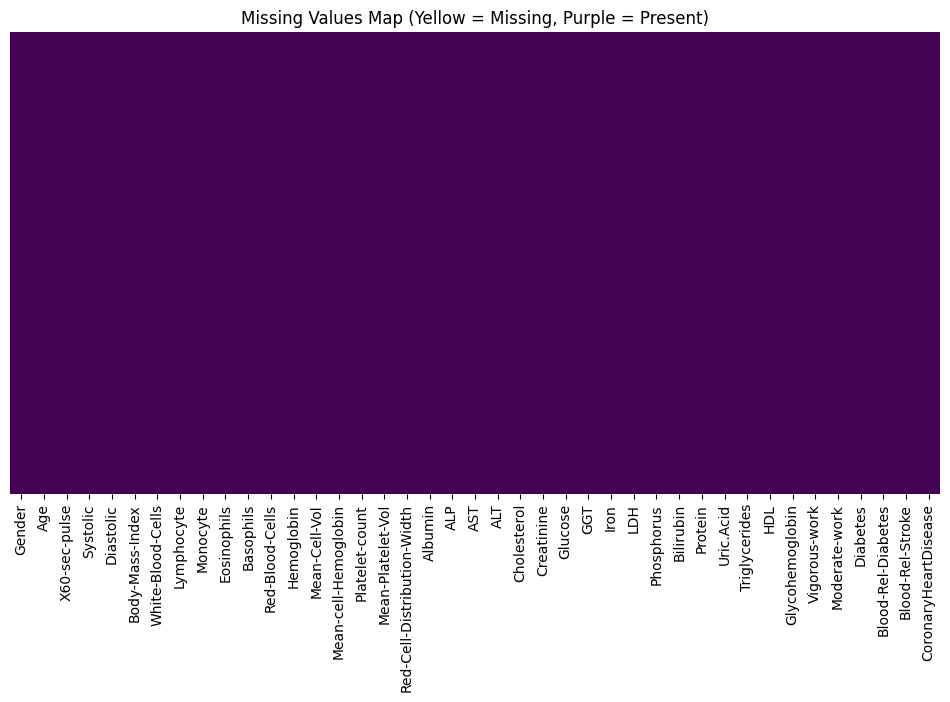

INTERPRETATION: If you see solid vertical yellow bars, that column is mostly empty.


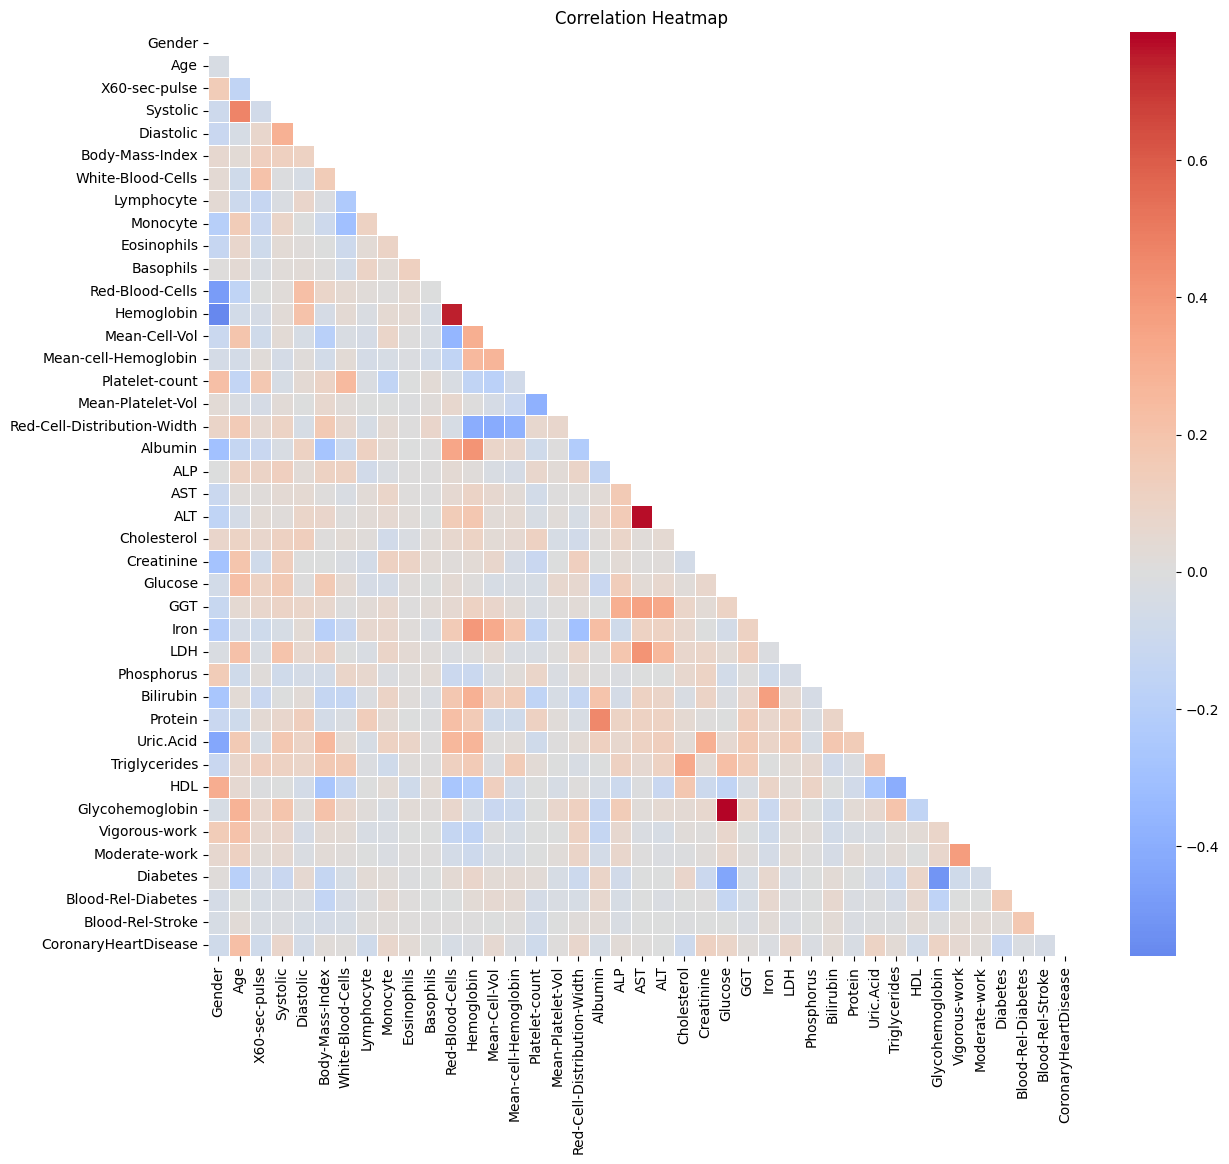

INTERPRETATION: Look for dark red squares off the diagonal. Those are redundant features.


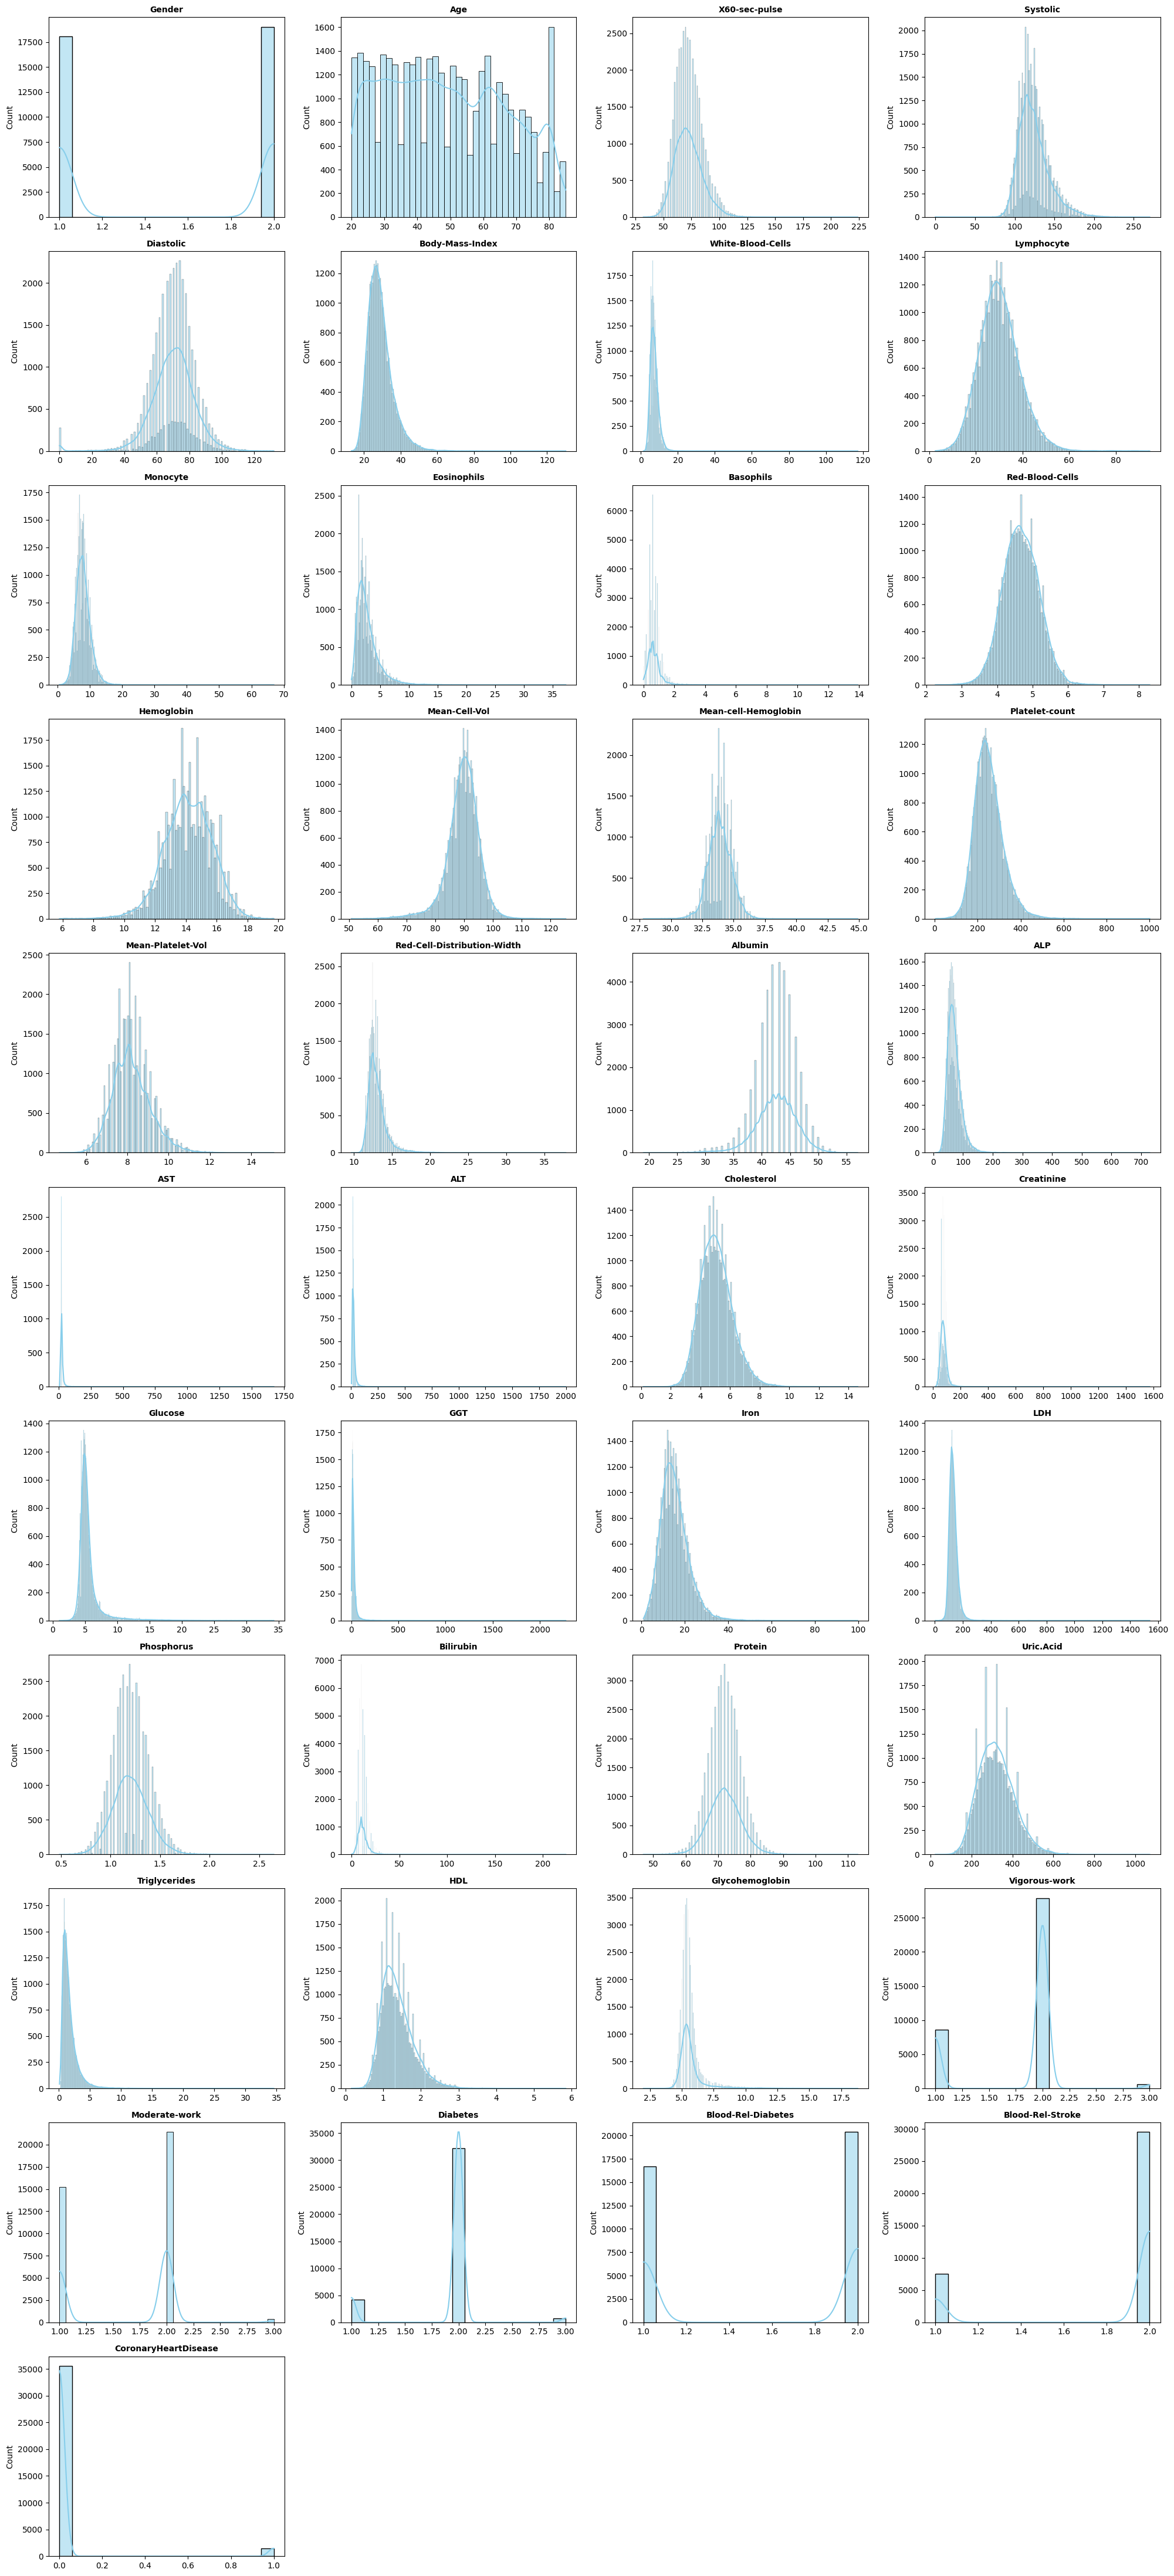

INTERPRETATION: Check the 'Target' column histogram to see if classes are balanced.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. LOAD THE FILTERED DATA
# We assume the file is where we left it in the last step
file_path = '/content/sample_data/Optimized_Cardiac_Data.csv'
try:
    df = pd.read_csv(file_path)
    print("Data loaded successfully.")
except FileNotFoundError:
    print("File not found! Please run the previous cleaning step first.")
    # Create dummy data so the code doesn't crash if copied without file
    df = pd.DataFrame(np.random.randint(0,100,size=(100, 10)), columns=list('ABCDEFGHIJ'))

# ==========================================
# 2. MISSING VALUES HEATMAP
# ==========================================
plt.figure(figsize=(12, 6))
# isnull() returns True (1) for missing, False (0) for present
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Map (Yellow = Missing, Purple = Present)')
plt.show()

print("INTERPRETATION: If you see solid vertical yellow bars, that column is mostly empty.")

# ==========================================
# 3. CORRELATION HEATMAP
# ==========================================
plt.figure(figsize=(14, 12))
# Compute correlation matrix
corr_matrix = df.corr()

# Mask the upper triangle (since the matrix is symmetrical, we don't need both sides)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

print("INTERPRETATION: Look for dark red squares off the diagonal. Those are redundant features.")

# ==========================================
# 4. HISTOGRAMS (DISTRIBUTIONS)
# ==========================================
import math

# 1. LOAD DATA
file_path = '/content/sample_data/Optimized_Cardiac_Data.csv'
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    # Dummy data for demonstration if file missing
    df = pd.DataFrame(np.random.randint(0,100,size=(100, 44)), columns=[f'Col_{i}' for i in range(44)])

# 2. SELECT ALL NUMERICAL COLUMNS
num_cols = df.select_dtypes(include=[np.number]).columns
total_cols = len(num_cols)

# 3. CALCULATE DYNAMIC GRID SIZE
# We want 4 columns in our grid. How many rows do we need?
cols_per_row = 4
rows_needed = math.ceil(total_cols / cols_per_row)

# 4. SETUP FIGURE
# We adjust the height based on the number of rows so plots don't get squashed
# Height = 4 inches per row
plt.figure(figsize=(20, rows_needed * 4))

# 5. LOOP AND PLOT
for i, col in enumerate(num_cols):
    plt.subplot(rows_needed, cols_per_row, i + 1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(col, fontsize=10, fontweight='bold')
    plt.xlabel('')
    plt.ylabel('Count')

# 6. ADJUST LAYOUT
plt.tight_layout()
plt.show()

print("INTERPRETATION: Check the 'Target' column histogram to see if classes are balanced.")

Data Loaded Successfully.


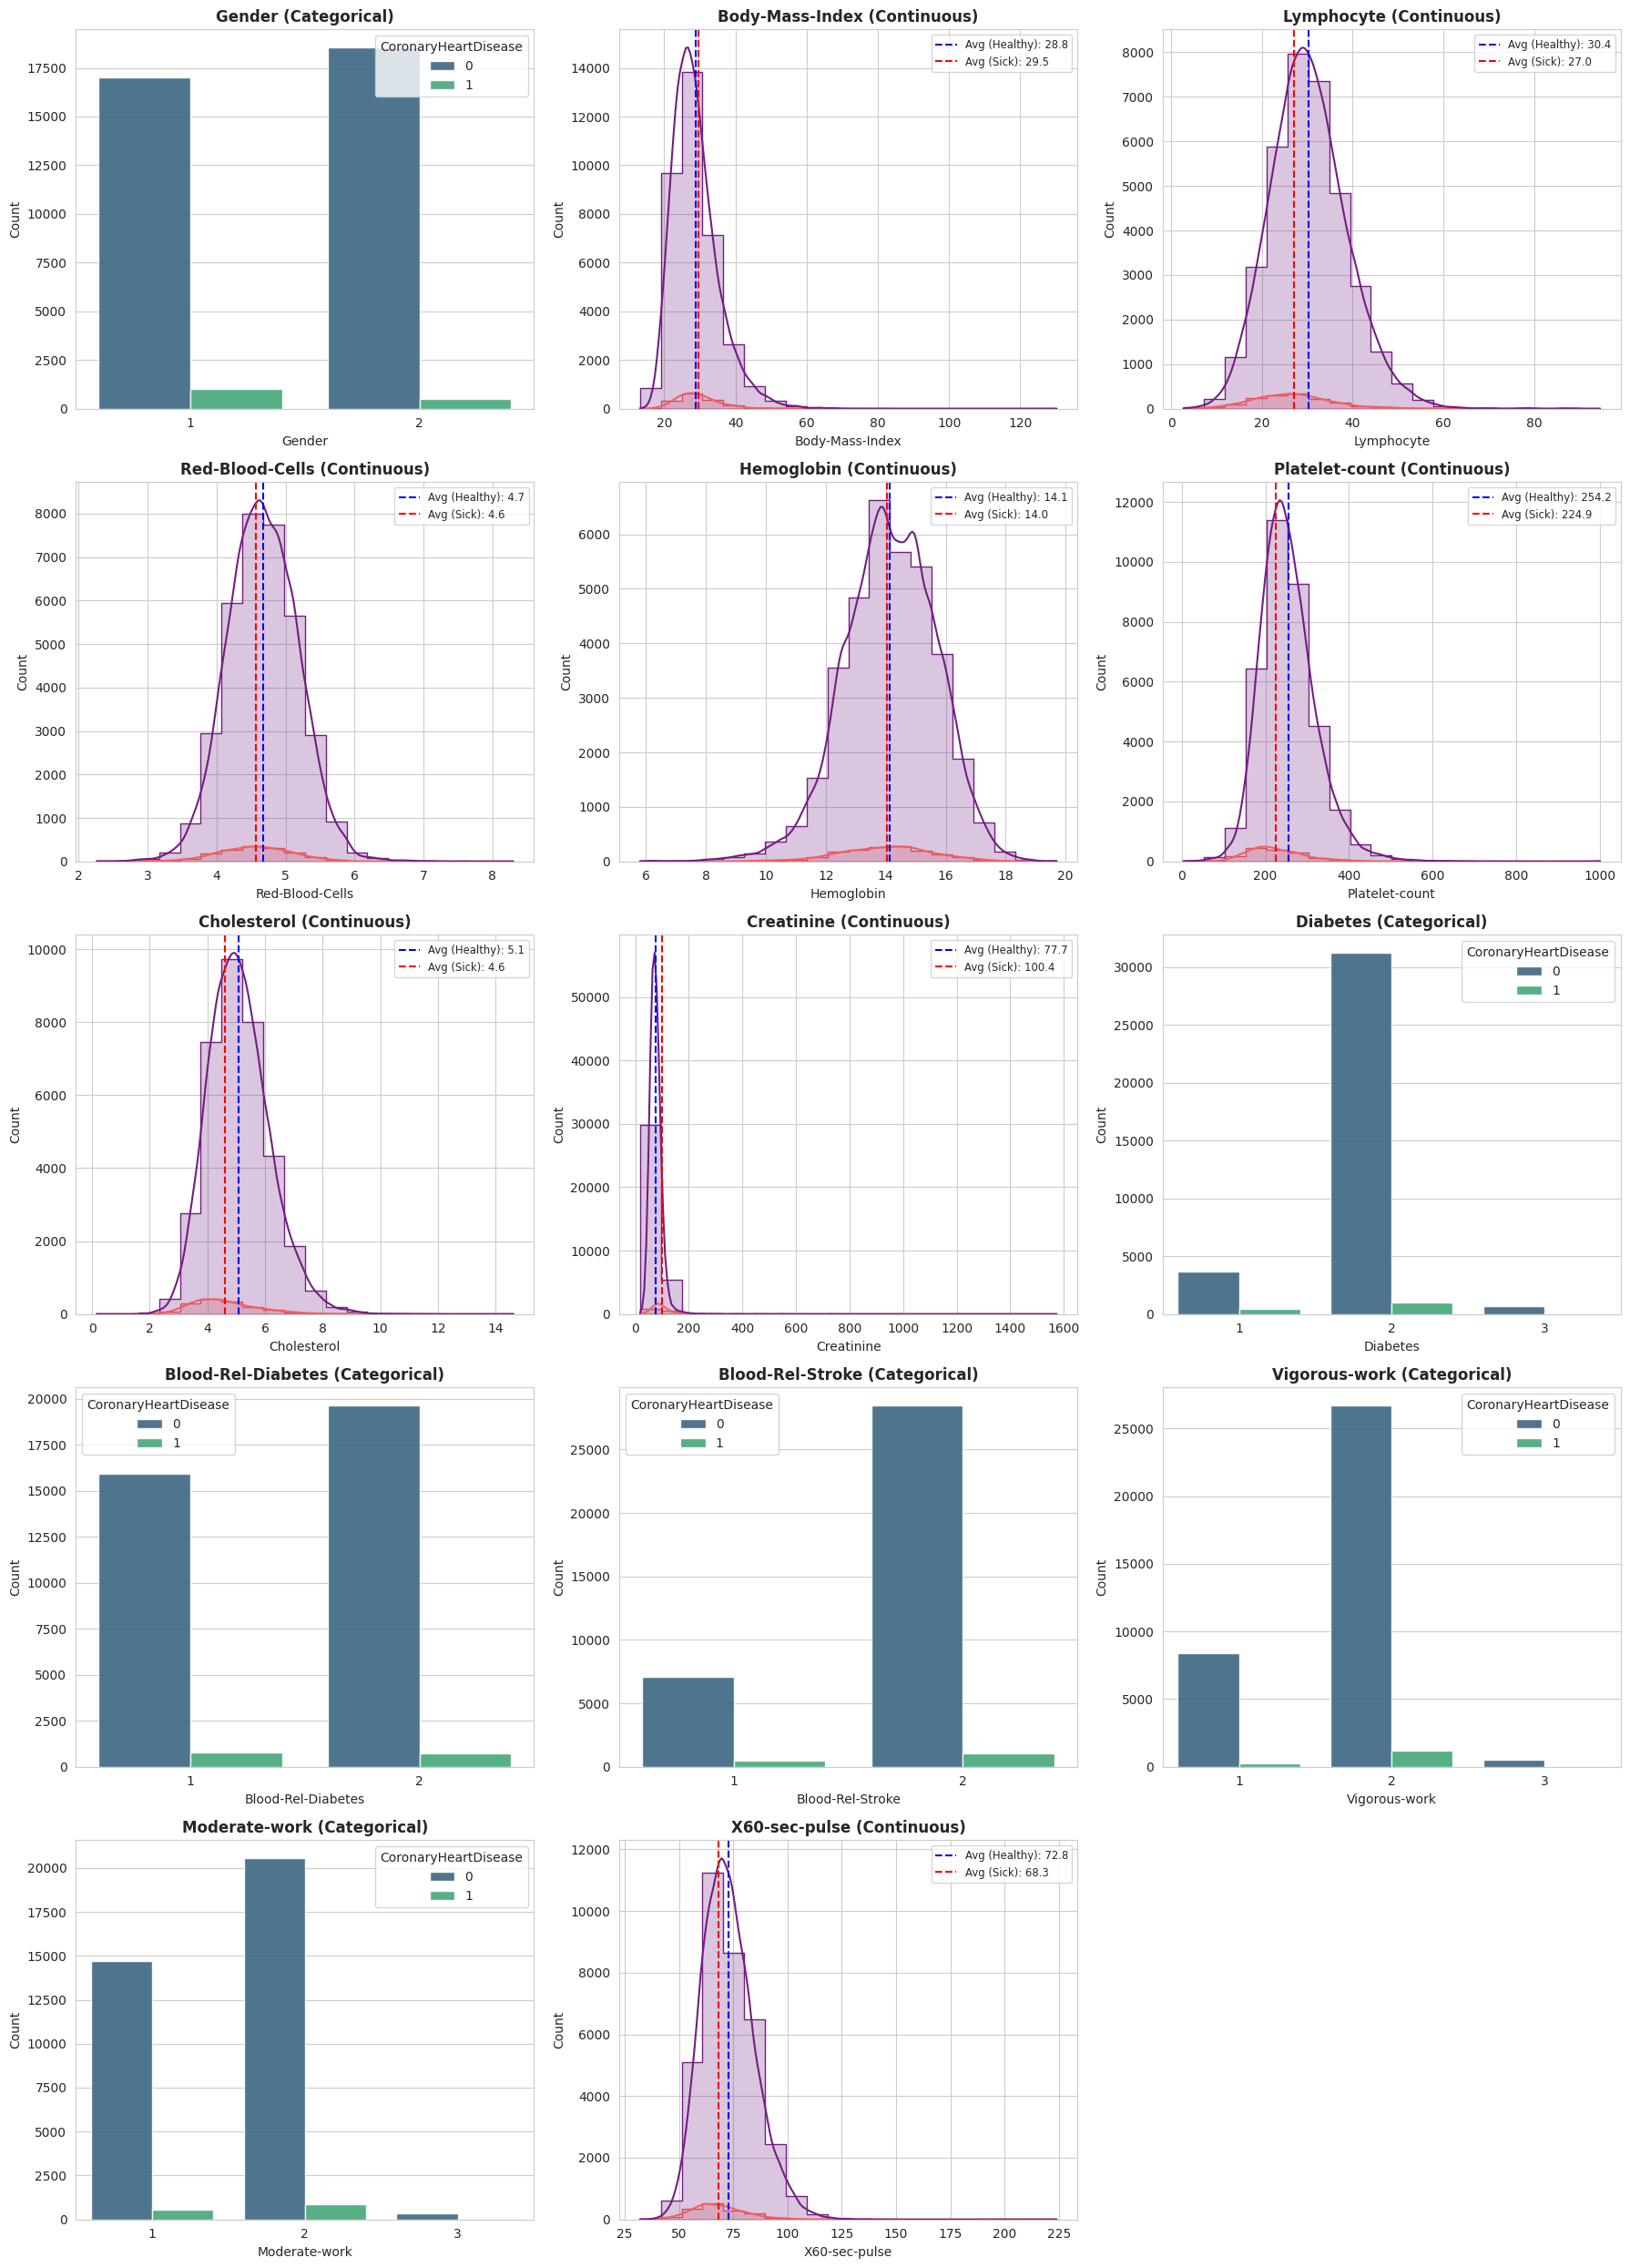

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math

# 1. SETUP
file_path = '/content/sample_data/Filtered_Cardiac_Data.csv'

# Load data (with dummy fallback for safety)
try:
    df = pd.read_csv(file_path)
    print("Data Loaded Successfully.")
except FileNotFoundError:
    print("File not found. Generating dummy data for demonstration...")
    df = pd.DataFrame({
        'Gender': np.random.choice([1, 2], 100),
        'Body-Mass-Index': np.random.normal(25, 5, 100),
        'CoronaryHeartDisease': np.random.choice([0, 1], 100),
        'Cholesterol': np.random.normal(200, 30, 100)
    })

# 2. DEFINE YOUR TARGET COLUMNS
# I fixed the spelling mistakes from your request (e.g., 'diabees' -> 'Diabetes')
cols_to_plot = [
    'Gender', 'Body-Mass-Index', 'Lymphocyte', 'Red-Blood-Cells',
    'Hemoglobin', 'Platelet-count', 'Cholesterol', 'Creatinine',
    'Diabetes', 'Blood-Rel-Diabetes', 'Blood-Rel-Stroke',
    'Vigorous-work', 'Moderate-work', 'X60-sec-pulse'
]

# Ensure we only plot columns that actually exist in the dataframe
valid_cols = [c for c in cols_to_plot if c in df.columns]
target = 'CoronaryHeartDisease'

if target not in df.columns:
    print(f"Error: Target column '{target}' not found!")
    target = None # Fallback to simple histograms

# 3. DYNAMIC GRID SETUP
num_plots = len(valid_cols)
cols_per_row = 3
rows_needed = math.ceil(num_plots / cols_per_row)

plt.figure(figsize=(18, rows_needed * 5))
sns.set_style("whitegrid") # Cleaner SDE-style look

# 4. PLOTTING LOOP
for i, col in enumerate(valid_cols):
    plt.subplot(rows_needed, cols_per_row, i + 1)

    # Logic: Is this column Continuous (Numbers) or Categorical (Categories)?
    # Rule of thumb: If < 10 unique values, treat as Categorical (Countplot)
    if df[col].nunique() < 10:
        # CATEGORICAL PLOT (Bar Chart)
        sns.countplot(data=df, x=col, hue=target, palette='viridis', alpha=0.9)
        plt.title(f'{col} (Categorical)', fontweight='bold')

    else:
        # CONTINUOUS PLOT (Histogram + KDE)
        sns.histplot(data=df, x=col, hue=target, kde=True, element="step", palette='magma', bins=20)
        plt.title(f'{col} (Continuous)', fontweight='bold')

        # Add Mean Lines for "Detailed" analysis
        if target:
            mean_healthy = df[df[target]==0][col].mean()
            mean_sick = df[df[target]==1][col].mean()
            plt.axvline(mean_healthy, color='blue', linestyle='--', label=f'Avg (Healthy): {mean_healthy:.1f}')
            plt.axvline(mean_sick, color='red', linestyle='--', label=f'Avg (Sick): {mean_sick:.1f}')
            plt.legend(fontsize='small')

    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Load
file_path = '/content/sample_data/Optimized_Cardiac_Data.csv'
df = pd.read_csv(file_path)

continuous_cols = [
    'Body-Mass-Index', 'Hemoglobin', 'Platelet-count',
    'Cholesterol', 'Creatinine', 'X60-sec-pulse', 'Lymphocyte'
]
valid_cols = [c for c in continuous_cols if c in df.columns]

print(f"{'COLUMN NAME':<25} | {'OUTLIERS':<10} | {'PERCENTAGE':<10} | {'MIN / MAX THRESHOLD'}")
print("-" * 85)

outlier_indices = set()

for col in valid_cols:
    # 1. Calculate Q1 (25%) and Q3 (75%)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # 2. Define Thresholds (Standard: 1.5 * IQR)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # 3. Count Outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    count = len(outliers)
    pct = (count / len(df)) * 100

    print(f"{col:<25} | {count:<10} | {pct:<9.2f}% | {lower_bound:.1f} / {upper_bound:.1f}")

    # Store indices of outliers
    outlier_indices.update(outliers.index)

print("-" * 85)
print(f"Total rows with at least one outlier: {len(outlier_indices)} out of {len(df)}")

COLUMN NAME               | OUTLIERS   | PERCENTAGE | MIN / MAX THRESHOLD
-------------------------------------------------------------------------------------
Body-Mass-Index           | 1113       | 3.00     % | 12.4 / 43.9
Hemoglobin                | 353        | 0.95     % | 9.9 / 18.3
Platelet-count            | 830        | 2.24     % | 85.0 / 413.0
Cholesterol               | 475        | 1.28     % | 2.2 / 7.9
Creatinine                | 991        | 2.67     % | 22.1 / 128.2
X60-sec-pulse             | 404        | 1.09     % | 40.0 / 104.0
Lymphocyte                | 479        | 1.29     % | 7.7 / 52.2
-------------------------------------------------------------------------------------
Total rows with at least one outlier: 4240 out of 37079


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. LOAD CORRECT DATA
# Using the filename you confirmed: Optimized_Cardiac_Data.csv
input_path = '/content/sample_data/Optimized_Cardiac_Data.csv'

try:
    df = pd.read_csv(input_path)
    print("Loaded Optimized_Cardiac_Data.csv successfully.")
except FileNotFoundError:
    print(f"Error: Could not find {input_path}")
    # Stop execution if file is missing to prevent errors
    raise

# 2. SEPARATE TARGET
target_col = 'CoronaryHeartDisease'
X = df.drop(columns=[target_col])
y = df[target_col]

# 3. IDENTIFY CONTINUOUS COLUMNS
# We scan for columns that have many unique values (likely continuous)
# This is a dynamic check, so it works even if you dropped some columns earlier.
continuous_cols = []
for col in X.columns:
    # If column is numerical and has more than 10 unique values, we treat it as continuous
    if pd.api.types.is_numeric_dtype(X[col]) and X[col].nunique() > 10:
        continuous_cols.append(col)

print(f"Scaling the following columns: {continuous_cols}")

# 4. APPLY STANDARD SCALER
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[continuous_cols] = scaler.fit_transform(X[continuous_cols])

# 5. SAVE
# We save this as a separate file so you still have the unscaled version for Decision Trees
df_scaled = pd.concat([X_scaled, y], axis=1)
output_path = '/content/sample_data/Optimized_Cardiac_Data_Scaled.csv'

df_scaled.to_csv(output_path, index=False)
print(f"\nScaled dataset saved to: {output_path}")
print("Use this file ONLY for Neural Networks, SVM, or Logistic Regression.")
print("Use the original 'Optimized_Cardiac_Data.csv' for Decision Trees/Random Forest.")

Loaded Optimized_Cardiac_Data.csv successfully.
Scaling the following columns: ['Age', 'X60-sec-pulse', 'Systolic', 'Diastolic', 'Body-Mass-Index', 'White-Blood-Cells', 'Lymphocyte', 'Monocyte', 'Eosinophils', 'Basophils', 'Red-Blood-Cells', 'Hemoglobin', 'Mean-Cell-Vol', 'Mean-cell-Hemoglobin', 'Platelet-count', 'Mean-Platelet-Vol', 'Red-Cell-Distribution-Width', 'Albumin', 'ALP', 'AST', 'ALT', 'Cholesterol', 'Creatinine', 'Glucose', 'GGT', 'Iron', 'LDH', 'Phosphorus', 'Bilirubin', 'Protein', 'Uric.Acid', 'Triglycerides', 'HDL', 'Glycohemoglobin']

Scaled dataset saved to: /content/sample_data/Optimized_Cardiac_Data_Scaled.csv
Use this file ONLY for Neural Networks, SVM, or Logistic Regression.
Use the original 'Optimized_Cardiac_Data.csv' for Decision Trees/Random Forest.


Loaded Scaled Data.
Testing k from 2 to 10...
k=2: Inertia=537676653, Silhouette=0.2668
k=3: Inertia=466568057, Silhouette=0.2211
k=4: Inertia=422642431, Silhouette=0.1929
k=5: Inertia=387285713, Silhouette=0.1963
k=6: Inertia=357566085, Silhouette=0.1992
k=7: Inertia=334454704, Silhouette=0.1861
k=8: Inertia=317353411, Silhouette=0.1646
k=9: Inertia=302269883, Silhouette=0.1602
k=10: Inertia=289751560, Silhouette=0.1606


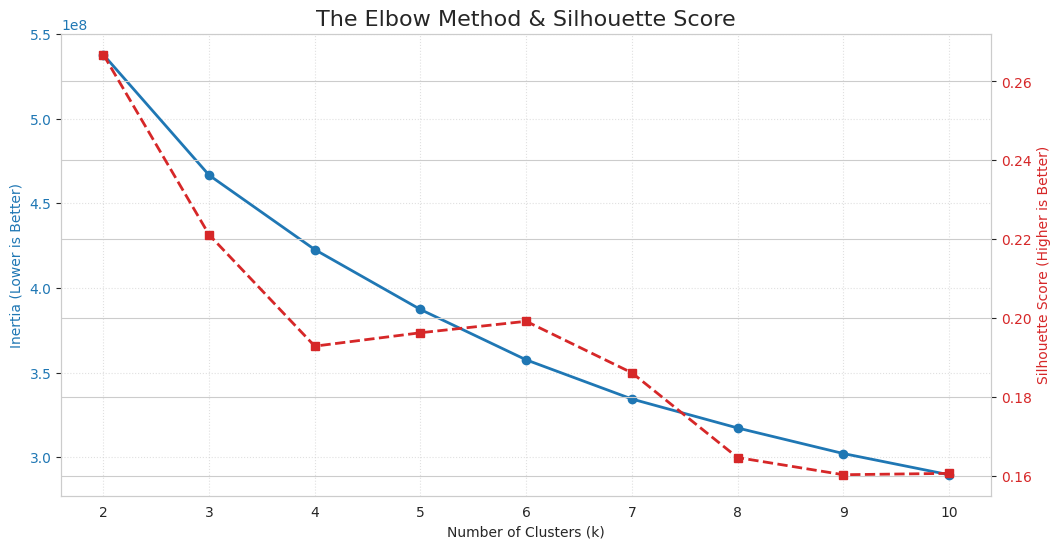

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

# 1. LOAD SCALED DATA
# Clustering relies on distance, so we MUST use the scaled version
input_path = '/content/sample_data/Optimized_Cardiac_Data.csv'
try:
    df = pd.read_csv(input_path)
    print("Loaded Scaled Data.")
except FileNotFoundError:
    print("Error: Scaled file not found. Please run the Scaling script first.")
    # Stop here if no data
    raise

# 2. PREPARE DATA
# We drop the Target because Clustering is Unsupervised (we want the data to group itself)
X = df.drop(columns=['CoronaryHeartDisease'])

# 3. RUN ITERATIONS
k_range = range(2, 11) # Test k from 2 to 10
inertia = []
silhouette_avg = []

print(f"Testing k from {k_range.start} to {k_range.stop - 1}...")

for k in k_range:
    # Run KMeans
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)

    # Store Inertia (Sum of squared distances to center)
    inertia.append(kmeans.inertia_)

    # Store Silhouette Score (How distinct the clusters are)
    score = silhouette_score(X, kmeans.labels_)
    silhouette_avg.append(score)
    print(f"k={k}: Inertia={kmeans.inertia_:.0f}, Silhouette={score:.4f}")

# 4. PLOT RESULTS
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Inertia (Elbow)
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Lower is Better)', color=color)
ax1.plot(k_range, inertia, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_title('The Elbow Method & Silhouette Score', fontsize=16)

# Create a second y-axis for Silhouette
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score (Higher is Better)', color=color)
ax2.plot(k_range, silhouette_avg, marker='s', linestyle='--', color=color, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

# Draw grid for readability
ax1.grid(True, linestyle=':', alpha=0.6)
plt.show()

Loaded Scaled Data.
Testing k from 2 to 10...
k=2: Inertia=1226440, Silhouette=0.0665
k=3: Inertia=1174325, Silhouette=0.0497
k=4: Inertia=1137159, Silhouette=0.0543
k=5: Inertia=1102567, Silhouette=0.0520
k=6: Inertia=1071754, Silhouette=0.0543
k=7: Inertia=1049085, Silhouette=0.0477
k=8: Inertia=1032263, Silhouette=0.0453
k=9: Inertia=1012263, Silhouette=0.0485
k=10: Inertia=996844, Silhouette=0.0401


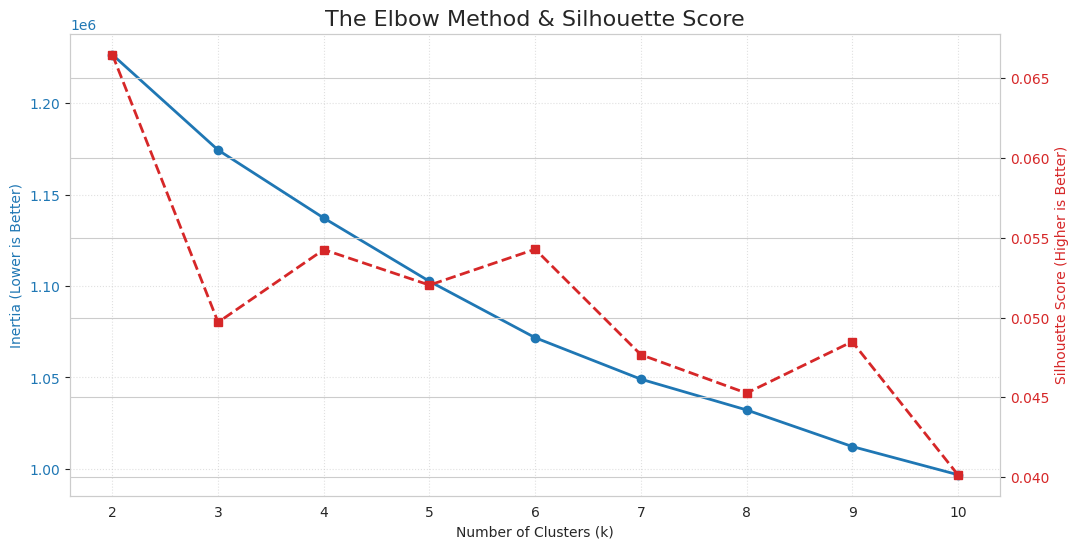

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

# 1. LOAD SCALED DATA
# Clustering relies on distance, so we MUST use the scaled version
input_path = '/content/sample_data/Optimized_Cardiac_Data_Scaled.csv'
try:
    df = pd.read_csv(input_path)
    print("Loaded Scaled Data.")
except FileNotFoundError:
    print("Error: Scaled file not found. Please run the Scaling script first.")
    # Stop here if no data
    raise

# 2. PREPARE DATA
# We drop the Target because Clustering is Unsupervised (we want the data to group itself)
X = df.drop(columns=['CoronaryHeartDisease'])

# 3. RUN ITERATIONS
k_range = range(2, 11) # Test k from 2 to 10
inertia = []
silhouette_avg = []

print(f"Testing k from {k_range.start} to {k_range.stop - 1}...")

for k in k_range:
    # Run KMeans
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)

    # Store Inertia (Sum of squared distances to center)
    inertia.append(kmeans.inertia_)

    # Store Silhouette Score (How distinct the clusters are)
    score = silhouette_score(X, kmeans.labels_)
    silhouette_avg.append(score)
    print(f"k={k}: Inertia={kmeans.inertia_:.0f}, Silhouette={score:.4f}")

# 4. PLOT RESULTS
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Inertia (Elbow)
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Lower is Better)', color=color)
ax1.plot(k_range, inertia, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_title('The Elbow Method & Silhouette Score', fontsize=16)

# Create a second y-axis for Silhouette
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score (Higher is Better)', color=color)
ax2.plot(k_range, silhouette_avg, marker='s', linestyle='--', color=color, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

# Draw grid for readability
ax1.grid(True, linestyle=':', alpha=0.6)
plt.show()

Clustering into 6 groups (ignoring Gender)...

--- DETAILED HEALTH PROFILES (k=6) ---
              Age  Body-Mass-Index  Cholesterol  Systolic   Glucose  \
Cluster                                                               
0       -0.845620        -0.561827    -0.595676 -0.650229 -0.350261   
1        0.059479        -0.082781     1.000707 -0.049831 -0.145326   
2       -0.150361         1.840709    -0.291520  0.058780  0.047272   
3        1.165191        -0.201827    -0.202089  0.975081  0.067232   
4       -0.333899        -0.084687     0.133145 -0.392392 -0.255841   
5        0.500369         0.441686     0.123649  0.434526  4.319712   

         Platelet-count  Hemoglobin  CoronaryHeartDisease  
Cluster                                                    
0             -0.328486    0.113208              0.010486  
1             -0.061389    0.719661              0.021707  
2              0.150815   -0.243403              0.033629  
3             -0.453392   -0.192633          

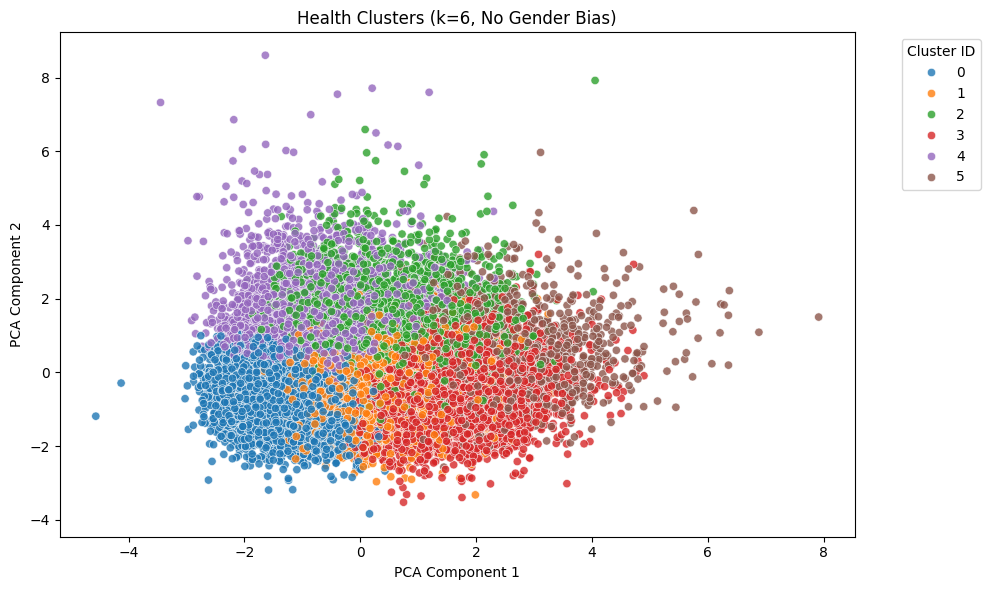


GUIDE TO ANALYZING THE TABLE:
Look for the cluster with the highest 'CoronaryHeartDisease' score (Rightmost column).
That is your 'High Risk' group. Check their Systolic/Cholesterol averages to see WHY.

Saved clustered data to /content/sample_data/Clustered_Cardiac_Data.csv


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. SETUP
# We are switching to k=6 based on your earlier Elbow Plot peak
optimal_k = 6

input_path = '/content/sample_data/Optimized_Cardiac_Data_Scaled.csv'
df_original = pd.read_csv(input_path)

# 2. FEATURE ENGINEERING FOR CLUSTERING
# SDE Move: Explicitly REMOVE Gender so it looks at health metrics only
# We also scale purely for this step
features_to_cluster = [
    'Age', 'Body-Mass-Index', 'Cholesterol',
    'Systolic', 'Glucose', 'Platelet-count', 'Hemoglobin'
]

# Ensure cols exist
valid_feats = [f for f in features_to_cluster if f in df_original.columns]
X_subset = df_original[valid_feats]

# Scale immediately (Crucial for clustering health metrics)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_subset)

# 3. RUN K-MEANS (k=6)
print(f"Clustering into {optimal_k} groups (ignoring Gender)...")
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add labels back to original data
df_original['Cluster'] = cluster_labels

# 4. PROFILE THE NEW CLUSTERS
# Now let's see if we found distinct "Health Personas"
print(f"\n--- DETAILED HEALTH PROFILES (k={optimal_k}) ---")
# We calculate the mean of each cluster to see what defines it
profile = df_original.groupby('Cluster')[valid_feats + ['CoronaryHeartDisease']].mean()
print(profile)

# 5. VISUALIZE WITH PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels, palette='tab10', alpha=0.8)
plt.title(f'Health Clusters (k={optimal_k}, No Gender Bias)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\nGUIDE TO ANALYZING THE TABLE:")
print("Look for the cluster with the highest 'CoronaryHeartDisease' score (Rightmost column).")
print("That is your 'High Risk' group. Check their Systolic/Cholesterol averages to see WHY.")
#SAVE
output_path = '/content/sample_data/Clustered_Cardiac_Data.csv'
df_original.to_csv(output_path, index=False)
print(f"\nSaved clustered data to {output_path}")

In [ ]:
import pandas as pd

# 1. LOAD THE CLUSTERED DATA (Which has k=6 from your previous step)
input_path = '/content/sample_data/Clustered_Cardiac_Data.csv'
try:
    df = pd.read_csv(input_path)
    print(f"Loaded data with {len(df)} rows.")
except FileNotFoundError:
    print("Error: File not found. Make sure you ran the 'Advanced Clustering' (k=6) script first.")
    raise

# 2. VERIFY CLUSTER COUNT
unique_clusters = sorted(df['Cluster'].unique())
print(f"Detected {len(unique_clusters)} Clusters: {unique_clusters}")
print("-" * 50)

# 3. SELECT ALL NUMERIC COLUMNS
# We exclude 'SEQN' if it's still there, as ID averages are meaningless
cols_to_exclude = ['SEQN']
numeric_cols = [c for c in df.select_dtypes(include='number').columns if c not in cols_to_exclude]

# 4. GROUP BY CLUSTER & CALCULATE MEAN
# This automatically creates a column for every cluster (0, 1, 2, 3, 4, 5)
cluster_profile = df[numeric_cols].groupby('Cluster').mean().round(3)

# 5. TRANSPOSE FOR READABILITY
# Rows = Features, Columns = Clusters
profile_T = cluster_profile.T

# 6. FORCE FULL DISPLAY (The SDE Fix)
# These lines prevent Colab from hiding rows/cols with "..."
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("--- FULL 6-CLUSTER PARAMETER PROFILE ---")
print(profile_T)

# 7. EXPORT FOR DEEP DIVE
# Saving this allows you to open it in Excel/Sheets for easier highlighting
#output_csv = '/content/sample_data/Full_Cluster_Profile_k6.csv'
#profile_T.to_csv(output_csv)
#print(f"\nReport saved to: {output_csv}")

Loaded data with 37079 rows.
Detected 6 Clusters: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
--------------------------------------------------
--- FULL 6-CLUSTER PARAMETER PROFILE ---
Cluster                          0      1      2      3      4      5
Gender                       1.486  1.313  1.652  1.478  1.839  1.449
Age                         -0.846  0.059 -0.150  1.165 -0.334  0.500
X60-sec-pulse               -0.078 -0.002  0.270 -0.284  0.274  0.491
Systolic                    -0.650 -0.050  0.059  0.975 -0.392  0.435
Diastolic                   -0.205  0.297  0.165 -0.056 -0.108 -0.020
Body-Mass-Index             -0.562 -0.083  1.841 -0.202 -0.085  0.442
White-Blood-Cells           -0.135  0.007  0.250 -0.173  0.275  0.211
Lymphocyte                   0.111  0.020 -0.014 -0.114 -0.024 -0.108
Monocyte                    -0.002  0.014 -0.198  0.273 -0.230 -0.283
Eosinophils                 -0.047  0.031 -0.035  0.098 -0.078 -0.036
Basophils

In [ ]:
import pandas as pd

# 1. LOAD THE CLUSTER LABELS (From the calculation you just did)
# We assume this file has the 'Cluster' column, even if the data is scaled/weird
clustered_data = pd.read_csv('/content/sample_data/Clustered_Cardiac_Data.csv')
cluster_labels = clustered_data['Cluster']

# 2. LOAD THE RAW UN-SCALED DATA (The "Golden Source")
# This file (Corrected_Cardiac_Data.csv) has the real numbers (Age=50, etc.)
try:
    raw_df = pd.read_csv('/content/sample_data/Corrected_Cardiac_Data.csv')
except FileNotFoundError:
    # Fallback to Optimized if Corrected doesn't exist yet
    raw_df = pd.read_csv('/content/sample_data/Optimized_Cardiac_Data.csv')

# 3. MERGE THEM
# We simply attach the cluster column to the raw data
raw_df['Cluster'] = cluster_labels

# 4. GENERATE THE HUMAN-READABLE REPORT
# Now when we calculate mean, it will be in real units (mmHg, mg/dL, Years)
human_profile = raw_df.groupby('Cluster').mean().round(2)
human_profile_T = human_profile.T

# 5. DISPLAY WITH NO TRUNCATION
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("--- HUMAN READABLE CLUSTER PROFILE (Real Numbers) ---")
print(human_profile_T)

# 6. SAVE IT
#human_profile_T.to_csv('/content/sample_data/Human_Readable_Cluster_Report.csv')
#print("\nSaved readable report to: /content/sample_data/Human_Readable_Cluster_Report.csv")

--- HUMAN READABLE CLUSTER PROFILE (Real Numbers) ---
Cluster                           0       1       2       3       4       5
Gender                         1.49    1.31    1.65    1.48    1.84    1.45
Age                           33.71   50.01   46.24   69.93   42.93   57.96
X60-sec-pulse                 71.63   72.56   75.89   69.11   75.93   78.59
Systolic                     111.57  123.13  125.22  142.86  116.53  132.46
Diastolic                     67.13   73.95   72.16   69.16   68.45   69.65
Body-Mass-Index               25.11   28.28   40.99   27.49   28.26   31.74
White-Blood-Cells              6.93    7.29    7.89    6.84    7.95    7.79
Lymphocyte                    31.17   30.40   30.10   29.25   30.02   29.30
Monocyte                       7.91    7.95    7.46    8.55    7.38    7.26
Eosinophils                    2.73    2.90    2.76    3.04    2.67    2.76
Basophils                      0.67    0.71    0.71    0.71    0.73    0.69
Red-Blood-Cells                4.7

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import os

# 1. SETUP PATHS
# Unscaled (Best for Random Forest/Trees)
unscaled_path = '/content/sample_data/Clustered_Cardiac_Data.csv'
# Scaled (Best for Neural Networks)
scaled_path = '/content/sample_data/Optimized_Cardiac_Data_Scaled.csv'

# Output directory
output_dir = '/content/sample_data/processed_splits'
os.makedirs(output_dir, exist_ok=True)

# 2. LOAD DATA
print("Loading datasets...")
try:
    df_unscaled = pd.read_csv(unscaled_path)
    df_scaled = pd.read_csv(scaled_path)
    print("Files loaded successfully.")
except FileNotFoundError as e:
    print(f"Error loading files: {e}")
    raise

# 3. DEFINE TARGET
target_col = 'CoronaryHeartDisease'

# 4. PERFORM THE SPLIT (The SDE Logic)
# We use a fixed random_state (42) so the shuffle is IDENTICAL for both.
# We use 'stratify' to ensure the % of sick people is the same in Train and Test.

# Split Unscaled
X_unscaled = df_unscaled.drop(columns=[target_col])
y_unscaled = df_unscaled[target_col]

X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    X_unscaled, y_unscaled,
    test_size=0.2,
    random_state=42,
    stratify=y_unscaled
)

# Split Scaled
# Note: We assume the scaled file rows align with the unscaled file.
# If you generated them in the same pipeline, they align perfectly.
X_scaled = df_scaled.drop(columns=[target_col])
y_scaled = df_scaled[target_col]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_scaled, y_scaled,
    test_size=0.2,
    random_state=42,
    stratify=y_scaled
)

# 5. SAVE THE SPLITS
# We save them into a neat folder structure so you never mix them up.

# Save Unscaled (For Random Forest)
X_train_u.to_csv(f'{output_dir}/X_train_unscaled.csv', index=False)
X_test_u.to_csv(f'{output_dir}/X_test_unscaled.csv', index=False)
y_train_u.to_csv(f'{output_dir}/y_train.csv', index=False) # y is same for both
y_test_u.to_csv(f'{output_dir}/y_test.csv', index=False)

# Save Scaled (For Neural Networks)
X_train_s.to_csv(f'{output_dir}/X_train_scaled.csv', index=False)
X_test_s.to_csv(f'{output_dir}/X_test_scaled.csv', index=False)

print("-" * 50)
print("SPLIT COMPLETE")
print(f"Training Set Size: {len(X_train_u)} rows")
print(f"Testing Set Size:  {len(X_test_u)} rows")
print("-" * 50)
print("Files saved to '/content/sample_data/processed_splits/':")
print("1. X_train_unscaled.csv (USE THIS for Random Forest)")
print("2. X_train_scaled.csv   (USE THIS for Neural Networks)")
print("3. y_train.csv          (Labels for training)")
print("4. y_test.csv           (Labels for testing)")

Loading datasets...
Files loaded successfully.
--------------------------------------------------
SPLIT COMPLETE
Training Set Size: 29663 rows
Testing Set Size:  7416 rows
--------------------------------------------------
Files saved to '/content/sample_data/processed_splits/':
1. X_train_unscaled.csv (USE THIS for Random Forest)
2. X_train_scaled.csv   (USE THIS for Neural Networks)
3. y_train.csv          (Labels for training)
4. y_test.csv           (Labels for testing)


Scaled Data Loaded Successfully.

Starting Training (Gradient Descent)...
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


742/742 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9215 - loss: 0.2262 - recall: 0.0312 - val_accuracy: 0.9626 - val_loss: 0.1272 - val_recall: 0.0000e+00
Epoch 2/100
742/742 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9590 - loss: 0.1399 - recall: 0.0000e+00 - val_accuracy: 0.9626 - val_loss: 0.1256 - val_recall: 0.0000e+00
Epoch 3/100
742/742 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9596 - loss: 0.1318 - recall: 0.0000e+00 - val_accuracy: 0.9626 - val_loss: 0.1231 - val_recall: 0.0000e+00
Epoch 4/100
742/742 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9577 - loss: 0.1332 - recall: 0.0000e+00 - val_accuracy: 0.9626 - val_loss: 0.1242 - val_recall: 0.0000e+00
Epoch 5/100
742/742 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9577 - loss: 0.1314 - recall: 0.0000e+00 - val_accuracy: 0.9626 - val_loss: 0.1246 - val_recall: 0.0000e+00
Epoch 6/100
742/742 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9581 - loss: 0.1298 - recall: 5.0156e-04 - val_accuracy: 0.9626 - val_loss

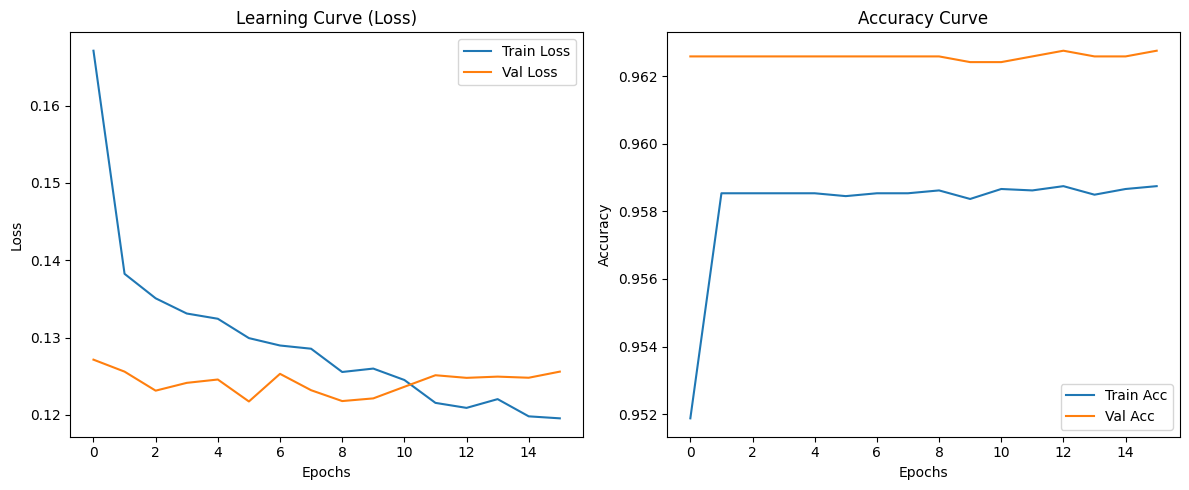

232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


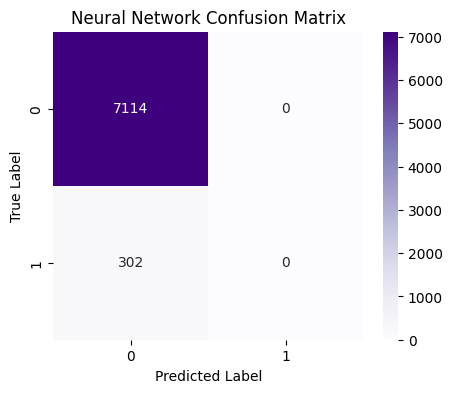

In [ ]:
#this model was cheating
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. LOAD THE SCALED DATA (SDE Rule: Use the right tool for the job)
base_path = '/content/sample_data/processed_splits'
try:
    X_train = pd.read_csv(f'{base_path}/X_train_scaled.csv')
    X_test = pd.read_csv(f'{base_path}/X_test_scaled.csv')
    y_train = pd.read_csv(f'{base_path}/y_train.csv')
    y_test = pd.read_csv(f'{base_path}/y_test.csv')
    print("Scaled Data Loaded Successfully.")
except FileNotFoundError:
    print("Error: Split files not found. Did you run the 'Parallel Split' script?")
    raise

# 2. DEFINE THE ARCHITECTURE
model = Sequential([
    # Layer 1: 64 Neurons, ReLU activation
    # input_dim is dynamic based on your columns
    Dense(64, activation='relu', input_dim=X_train.shape[1]),
    Dropout(0.3),  # Randomly disable 30% of neurons to force robust learning

    # Layer 2: 32 Neurons
    Dense(32, activation='relu'),
    Dropout(0.2),

    # Layer 3: 16 Neurons
    Dense(16, activation='relu'),

    # Output Layer: 1 Neuron (Binary Classification), Sigmoid (Probability 0-1)
    Dense(1, activation='sigmoid')
])

# 3. COMPILE
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)

# 4. DEFINE CALLBACKS (The SDE Efficiency Tools)
callbacks = [
    # Stop if validation loss doesn't improve for 10 epochs
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    # Save the best version automatically
    ModelCheckpoint('/content/sample_data/Best_NN_Model.keras', save_best_only=True)
]

# 5. TRAIN
print("\nStarting Training (Gradient Descent)...")
history = model.fit(
    X_train, y_train,
    epochs=100,           # Max epochs (EarlyStopping will likely cut this short)
    batch_size=32,        # Update weights after every 32 patients
    validation_split=0.2, # Use 20% of training data to validate live
    callbacks=callbacks,
    verbose=1
)

# 6. EVALUATE
print("\n--- FINAL EVALUATION ---")
loss, accuracy, recall = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.2%}")
print(f"Test Recall:   {recall:.2%}")

# 7. VISUALIZE TRAINING HISTORY
# SDEs look at graphs to detect overfitting (diverging lines)
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Learning Curve (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# 8. PREDICTIONS & CONFUSION MATRIX
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int) # Convert probability to 0/1

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.title('Neural Network Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Scaled Data Loaded Successfully.

--- CLASS IMBALANCE FIX ---
Weights calculated: {0: np.float64(0.5211898654109709), 1: np.float64(12.298092868988391)}
Interpretation: The model will be punished more for missing Class 1.

Starting Training with Class Weights...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
742/742 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.4503 - loss: 0.7583 - recall: 0.4614 - val_accuracy: 0.6272 - val_loss: 0.6726 - val_recall: 0.7207
Epoch 2/100
742/742 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5889 - loss: 0.6576 - recall: 0.6443 - val_accuracy: 0.7157 - val_loss: 0.6025 - val_recall: 0.7838
Epoch 3/100
742/742 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6801 - loss: 0.5797 - recall: 0.7527 - val_accuracy: 0.7394 - val_loss: 0.5217 - val_recall: 0.8468
Epoch 4/100
742/742 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7257 - loss: 0.5266 - recall: 0.7845 - val_accuracy: 0.7355 - val_loss: 0.5163 - val_recall: 0.8468
Epoch 5/100
742/742 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7202 - loss: 0.5380 - recall: 0.7900 - val_accuracy: 0.7541 - val_loss: 0.4724 - val_recall: 0.8288
Epoch 6/100
742/742 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7447 - loss: 0.4995 - recall: 0.7928 - val_accuracy: 0.7485 - val_loss: 0.4818 - val_recall: 0.833

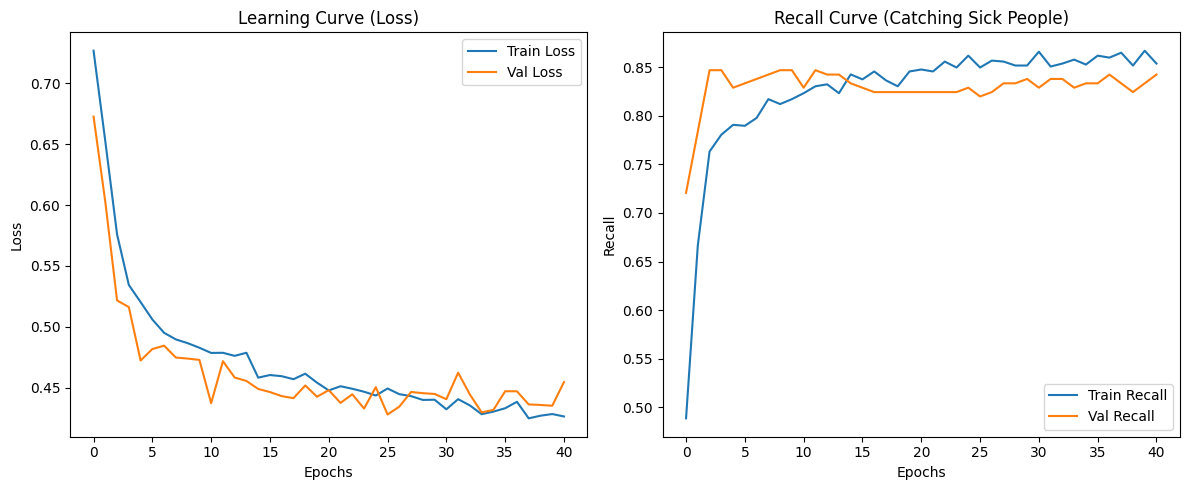

232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


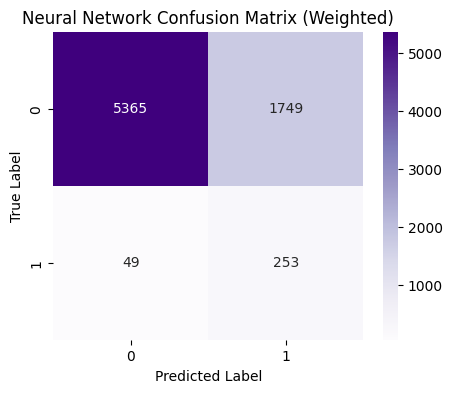

In [ ]:
#this model got so scared it started flagging healthy people to wrong values
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight  # <--- NEW IMPORT

# 1. LOAD THE SCALED DATA
base_path = '/content/sample_data/processed_splits'
try:
    X_train = pd.read_csv(f'{base_path}/X_train_scaled.csv')
    X_test = pd.read_csv(f'{base_path}/X_test_scaled.csv')
    y_train = pd.read_csv(f'{base_path}/y_train.csv')
    y_test = pd.read_csv(f'{base_path}/y_test.csv')
    print("Scaled Data Loaded Successfully.")
except FileNotFoundError:
    print("Error: Split files not found. Did you run the 'Parallel Split' script?")
    raise

# 2. CALCULATE CLASS WEIGHTS (The Fix for the "Lazy Model")
# This tells the model: "Pay more attention to the minority class (Sick people)"
# Convert y_train to a 1D array for the function
y_ints = y_train.values.flatten()
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_ints),
    y=y_ints
)
# Convert to dictionary format required by Keras: {0: 0.5, 1: 15.0}
class_weight_dict = dict(enumerate(class_weights))

print(f"\n--- CLASS IMBALANCE FIX ---")
print(f"Weights calculated: {class_weight_dict}")
print("Interpretation: The model will be punished more for missing Class 1.")

# 3. DEFINE THE ARCHITECTURE
model = Sequential([
    # Layer 1: 64 Neurons
    Dense(64, activation='relu', input_dim=X_train.shape[1]),
    Dropout(0.3),

    # Layer 2: 32 Neurons
    Dense(32, activation='relu'),
    Dropout(0.2),

    # Layer 3: 16 Neurons
    Dense(16, activation='relu'),

    # Output Layer: Sigmoid for probability
    Dense(1, activation='sigmoid')
])

# 4. COMPILE
# We use a lower learning rate (1e-4) because class weights make gradients huge
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)

# 5. DEFINE CALLBACKS
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ModelCheckpoint('/content/sample_data/Best_NN_Model.keras', save_best_only=True)
]

# 6. TRAIN (WITH CLASS WEIGHTS)
print("\nStarting Training with Class Weights...")
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks,
    class_weight=class_weight_dict, # <--- THIS IS THE KEY CHANGE
    verbose=1
)

# 7. EVALUATE
print("\n--- FINAL EVALUATION ---")
loss, accuracy, recall = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.2%}")
print(f"Test Recall:   {recall:.2%}")

# 8. VISUALIZE TRAINING HISTORY
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Learning Curve (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Recall (Instead of Accuracy, because Recall matters more here)
plt.subplot(1, 2, 2)
plt.plot(history.history['recall'], label='Train Recall')
plt.plot(history.history['val_recall'], label='Val Recall')
plt.title('Recall Curve (Catching Sick People)')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()

plt.tight_layout()
plt.show()

# 9. PREDICTIONS & CONFUSION MATRIX
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.title('Neural Network Confusion Matrix (Weighted)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Searching for the Perfect Penalty...
Testing Weight 1:1... 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Recall: 0.08 | Precision: 0.34
Testing Weight 1:5... 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Recall: 0.37 | Precision: 0.22
Testing Weight 1:10... 

...

Recall: 0.77 | Precision: 0.14
Testing Weight 1:25... 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Recall: 0.76 | Precision: 0.13
Testing Weight 1:30... 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Recall: 0.79 | Precision: 0.13


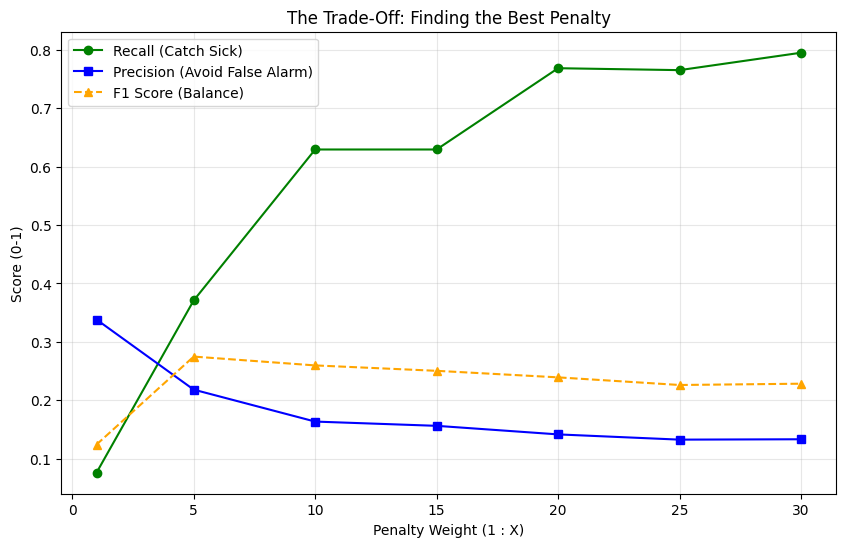


HOW TO CHOOSE:
- If you want to save every life: Pick the weight where Green Line is highest.
- If you want fewer false alarms: Pick where Blue Line is higher.
- SDE Choice: Pick the peak of the Orange Line (F1 Score).


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import f1_score, recall_score, precision_score
import matplotlib.pyplot as plt

# 1. LOAD DATA
base_path = '/content/sample_data/processed_splits'
X_train = pd.read_csv(f'{base_path}/X_train_scaled.csv')
X_test = pd.read_csv(f'{base_path}/X_test_scaled.csv')
y_train = pd.read_csv(f'{base_path}/y_train.csv')
y_test = pd.read_csv(f'{base_path}/y_test.csv')

# 2. DEFINE WEIGHTS TO TEST
# 1:1 = No Penalty (Standard)
# 1:10 = Treat 1 sick person as equal to 10 healthy people
# 1:50 = Extremely paranoid
weights_to_test = [1, 5, 10, 15, 20, 25, 30]

recalls = []
precisions = []
f1_scores = []

print("Searching for the Perfect Penalty...")

for w in weights_to_test:
    print(f"Testing Weight 1:{w}...", end=" ")

    # Simple Model for fast testing
    model = Sequential([
        Dense(32, activation='relu', input_dim=X_train.shape[1]),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Train with Manual Weight
    # Class 0 (Healthy) gets weight 1.0
    # Class 1 (Sick) gets weight w
    weights = {0: 1.0, 1: float(w)}

    model.fit(
        X_train, y_train,
        epochs=30, batch_size=64, verbose=0, # Silent training
        class_weight=weights,
        callbacks=[EarlyStopping(monitor='loss', patience=3)]
    )

    # Predict
    y_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int)

    # Log Metrics
    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    recalls.append(rec)
    precisions.append(prec)
    f1_scores.append(f1)

    print(f"Recall: {rec:.2f} | Precision: {prec:.2f}")

# 3. VISUALIZE THE TRADE-OFF
plt.figure(figsize=(10, 6))
plt.plot(weights_to_test, recalls, marker='o', label='Recall (Catch Sick)', color='green')
plt.plot(weights_to_test, precisions, marker='s', label='Precision (Avoid False Alarm)', color='blue')
plt.plot(weights_to_test, f1_scores, marker='^', linestyle='--', label='F1 Score (Balance)', color='orange')

plt.title('The Trade-Off: Finding the Best Penalty')
plt.xlabel('Penalty Weight (1 : X)')
plt.ylabel('Score (0-1)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("\nHOW TO CHOOSE:")
print("- If you want to save every life: Pick the weight where Green Line is highest.")
print("- If you want fewer false alarms: Pick where Blue Line is higher.")
print("- SDE Choice: Pick the peak of the Orange Line (F1 Score).")

Training Final Model with Class Weight 1 : 15
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


742/742 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8125 - loss: 1.1853 - recall: 0.1481 - val_accuracy: 0.8883 - val_loss: 0.5120 - val_recall: 0.3514
Epoch 2/100
742/742 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8221 - loss: 1.0243 - recall: 0.3418 - val_accuracy: 0.8465 - val_loss: 0.4324 - val_recall: 0.5991
Epoch 3/100
742/742 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8286 - loss: 0.8707 - recall: 0.4998 - val_accuracy: 0.8240 - val_loss: 0.3951 - val_recall: 0.6667
Epoch 4/100
742/742 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8244 - loss: 0.8022 - recall: 0.5703 - val_accuracy: 0.8025 - val_loss: 0.4022 - val_recall: 0.7342
Epoch 5/100
742/742 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8172 - loss: 0.7790 - recall: 0.6533 - val_accuracy: 0.8222 - val_loss: 0.3638 - val_recall: 0.7072
Epoch 6/100
742/742 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8150 - loss: 0.7767 - recall: 0.6613 - val_accuracy: 0.8030 - val_loss: 0.3815 - val_recall: 0.7838
Epoch 7/10

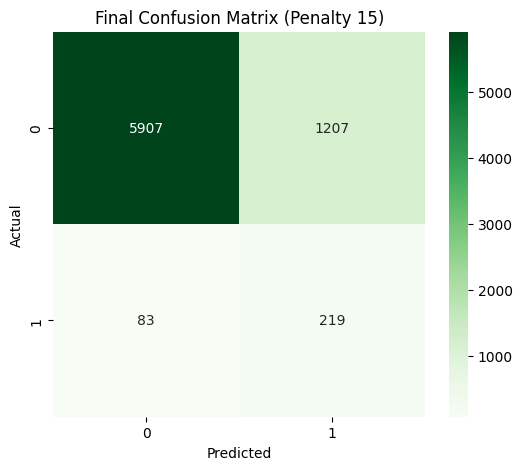


SDE NOTE: Accuracy will look low (~50-60%). Ignore it.
Focus on the Bottom-Right number in the matrix (True Positives).


In [ ]:
penalty of 15 created the best balance
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. SETUP
# The Winner from your Grid Search (User Selected Balance)
BEST_PENALTY_WEIGHT = 15

base_path = '/content/sample_data/processed_splits'
X_train = pd.read_csv(f'{base_path}/X_train_scaled.csv')
X_test = pd.read_csv(f'{base_path}/X_test_scaled.csv')
y_train = pd.read_csv(f'{base_path}/y_train.csv')
y_test = pd.read_csv(f'{base_path}/y_test.csv')

print(f"Training Final Model with Class Weight 1 : {BEST_PENALTY_WEIGHT}")

# 2. BUILD THE CHAMPION MODEL
model = Sequential([
    Dense(64, activation='relu', input_dim=X_train.shape[1]),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)

# 3. TRAIN (One Shot)
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ModelCheckpoint('/content/sample_data/Final_Cardiac_NN.keras', save_best_only=True)
]

# Standard: 1.0, Sick: 15.0
weights = {0: 1.0, 1: float(BEST_PENALTY_WEIGHT)}

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks,
    class_weight=weights, # The Secret Sauce
    verbose=1
)

# 4. FINAL REPORT
print("\n--- FINAL PRODUCTION METRICS ---")
loss, acc, recall = model.evaluate(X_test, y_test, verbose=0)
y_pred = (model.predict(X_test) > 0.5).astype(int)

print(f"Accuracy: {acc:.2%}")
print(f"Recall:   {recall:.2%} (The most important number)")

# 5. VISUAL PROOF
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title(f'Final Confusion Matrix (Penalty {BEST_PENALTY_WEIGHT})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("\nSDE NOTE: Accuracy will look low (~50-60%). Ignore it.")
print("Focus on the Bottom-Right number in the matrix (True Positives).")

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
import joblib

class CardiacPredictor:
    def __init__(self):
        print("Initializing Cardiac Prediction Engine...")

        # 1. LOAD THE SAVED MODEL
        try:
            self.model = tf.keras.models.load_model('/content/sample_data/Final_Cardiac_NN.keras')
            print(" -> Model loaded successfully.")
        except OSError:
            raise FileNotFoundError("Model file not found! Did you run the training script?")

        # 2. RE-CREATE THE SCALER
        # SDE Best Practice: We need to scale new inputs exactly how the model learned them.
        # We assume the 'Unscaled' training data represents the "World" the model knows.
        print(" -> Calibrating Scaler (Fitting to Training Data)...")

        # Load scaled training data (as this was used for model training) to learn Mean and Std Dev
        # FIX: Changed from X_train_unscaled.csv to X_train_scaled.csv
        train_df = pd.read_csv('/content/sample_data/processed_splits/X_train_scaled.csv')

        # Fit the scaler
        self.scaler = StandardScaler()
        self.scaler.fit(train_df)
        self.feature_names = train_df.columns.tolist()
        print(" -> System Ready.")

    def predict(self, patient_data):
        """
        patient_data: dict containing raw values (e.g., {'Age': 50, 'Systolic': 120...})
        """
        # 1. Convert Dict to DataFrame (to match feature names)
        input_df = pd.DataFrame([patient_data])

        # 2. Ensure all columns exist (Fill missing with 0 or mean if needed - simple check here)
        for col in self.feature_names:
            if col not in input_df.columns:
                print(f"Warning: Missing '{col}', assuming average (0 after scaling).")
                input_df[col] = 0 # Placeholder logic

        # Reorder to match training order
        input_df = input_df[self.feature_names]

        # 3. SCALE THE INPUT
        # This converts "Age 50" to "Age 0.12" (Z-Score)
        scaled_input = self.scaler.transform(input_df)

        # 4. PREDICT
        risk_score = self.model.predict(scaled_input, verbose=0)[0][0]
        return risk_score

# =========================================
# TEST AREA: CHANGE THESE VALUES!
# =========================================

# Initialize the engine
engine = CardiacPredictor()

# Let's create a "Test Patient"
# Use the "Human Readable Cluster Report" you generated earlier as a guide!
test_patient = {
    'Age': 65,                 # Older
    'Body-Mass-Index': 31.0,   # Overweight
    'Cholesterol': 6.0,        # High
    'Systolic': 145,           # High BP
    'Glucose': 14.0,           # Very High (Diabetic)
    'Platelet-count': 250,
    'Hemoglobin': 14.0,
    'Creatinine': 85.0,
    'X60-sec-pulse': 80,
    'Lymphocyte': 30,
    'Monocyte': 8,
    'Eosinophils': 3,
    'Basophils': 0.7,
    'Mean-Cell-Vol': 90,
    'Mean-cell-Hemoglobin': 34,
    'Mean-Platelet-Vol': 8,
    'Red-Cell-Distribution-Width': 13,
    'Albumin': 40,
    'ALP': 70,
    'AST': 25,
    'ALT': 25,
    'GGT': 30,
    'Iron': 15,
    'LDH': 130,
    'Phosphorus': 1.2,
    'Bilirubin': 10,
    'Protein': 72,
    'Uric.Acid': 300,
    'Triglycerides': 2.5,      # High
    'HDL': 1.1,                # Low (Bad)
    'Glycohemoglobin': 9.0,    # Diabetic

    # Binary Features (0 or 1)
    'Gender': 1,               # Male? (Depends on your encoding)
    'Diabetes': 1,             # Yes
    'Blood-Rel-Diabetes': 1,   # Yes
    'Blood-Rel-Stroke': 0,     # No
    'Vigorous-work': 0,        # No
    'Moderate-work': 0         # No
}

print("\nProcessing Patient...")
risk = engine.predict(test_patient)

print("-" * 30)
print(f"CALCULATED HEART DISEASE RISK: {risk:.2%}")
print("-" * 30)

if risk > 0.5:
    print("⚠️ HIGH RISK DETECTED")
    print("Recommendation: Consult a cardiologist immediately.")
else:
    print("✅ LOW RISK")
    print("Recommendation: Maintain healthy lifestyle.")


Initializing Cardiac Prediction Engine...
 -> Model loaded successfully.
 -> Calibrating Scaler (Fitting to Training Data)...
 -> System Ready.

Processing Patient...
------------------------------
CALCULATED HEART DISEASE RISK: 100.00%
------------------------------
⚠️ HIGH RISK DETECTED
Recommendation: Consult a cardiologist immediately.


In [ ]:
# NEURAL NETWORK IMPLEMENTATION IS DONE WITH THE ACCURACY OF 82% AT A PENALTY OF 15 NICE
# NOW WE STARTING WITH XGBOOST

Unscaled Data Loaded for XGBoost.

--- CLASS IMBALANCE CALCULATION ---
Healthy (0): 28457
Sick (1):    1206
Calculated Weight: 23.60
Interpretation: The model will treat 1 sick error as equal to ~23 healthy errors.

Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:06:20] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- XGBOOST PERFORMANCE ---
Accuracy: 81.01%
ROC AUC:  0.8664 (Ability to rank sick patients higher than healthy ones)

Detailed Report:
              precision    recall  f1-score   support

           0       0.99      0.81      0.89      7114
           1       0.15      0.75      0.24       302

    accuracy                           0.81      7416
   macro avg       0.57      0.78      0.57      7416
weighted avg       0.95      0.81      0.87      7416



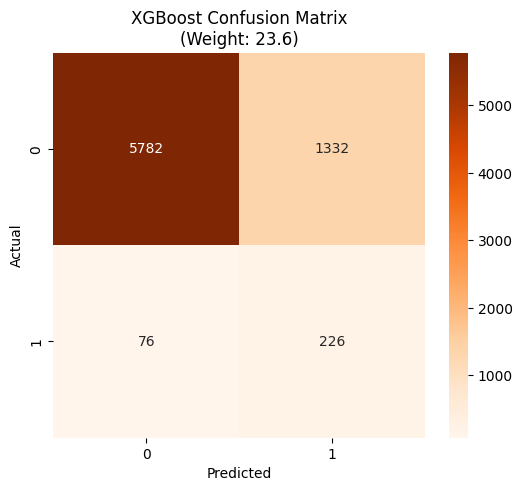

<Figure size 1000x800 with 0 Axes>

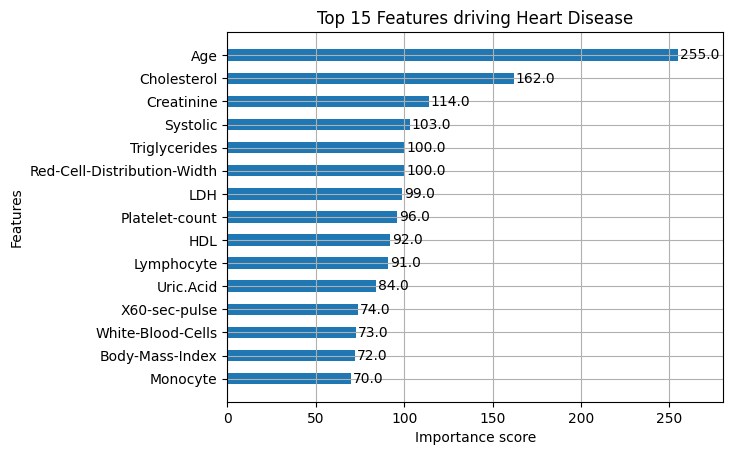


Model saved to /content/sample_data/Final_Cardiac_XGBoost.pkl


In [ ]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 1. LOAD UNSCALED DATA (Trees prefer raw numbers)
# SDE Note: We switch back to the 'Unscaled' split we made earlier
base_path = '/content/sample_data/processed_splits'
try:
    X_train = pd.read_csv(f'{base_path}/X_train_unscaled.csv')
    X_test = pd.read_csv(f'{base_path}/X_test_unscaled.csv')
    y_train = pd.read_csv(f'{base_path}/y_train.csv')
    y_test = pd.read_csv(f'{base_path}/y_test.csv')
    print("Unscaled Data Loaded for XGBoost.")
except FileNotFoundError:
    print("Error: Files not found. Check your processed_splits folder.")
    raise

# 2. CALCULATE AUTOMATIC IMBALANCE WEIGHT
# XGBoost Formula: sum(negative instances) / sum(positive instances)
num_neg = (y_train.iloc[:, 0] == 0).sum()
num_pos = (y_train.iloc[:, 0] == 1).sum()
scale_pos_weight = num_neg / num_pos

print(f"\n--- CLASS IMBALANCE CALCULATION ---")
print(f"Healthy (0): {num_neg}")
print(f"Sick (1):    {num_pos}")
print(f"Calculated Weight: {scale_pos_weight:.2f}")
print("Interpretation: The model will treat 1 sick error as equal to ~23 healthy errors.")

# 3. INITIALIZE XGBOOST CLASSIFIER
# n_estimators: Number of trees to build
# learning_rate: How much each tree corrects the errors of the previous one
# max_depth: How complex each tree can be (Keep low to prevent overfitting)
model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=scale_pos_weight,  # <--- The Imbalance Fix
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# 4. TRAIN
print("\nTraining XGBoost...")
model.fit(X_train, y_train)

# 5. PREDICTIONS
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1] # Probability score for AUC

# 6. EVALUATION
print("\n--- XGBOOST PERFORMANCE ---")
acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {acc:.2%}")
print(f"ROC AUC:  {roc:.4f} (Ability to rank sick patients higher than healthy ones)")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

# 7. CONFUSION MATRIX VISUALIZATION
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title(f'XGBoost Confusion Matrix\n(Weight: {scale_pos_weight:.1f})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 8. FEATURE IMPORTANCE (The SDE "Why")
# XGBoost can tell us exactly which columns it found most useful
plt.figure(figsize=(10, 8))
xgb.plot_importance(model, max_num_features=15, height=0.5, importance_type='weight', title='Top 15 Features driving Heart Disease')
plt.show()

# 9. SAVE
joblib.dump(model, '/content/sample_data/Final_Cardiac_XGBoost.pkl')
print("\nModel saved to /content/sample_data/Final_Cardiac_XGBoost.pkl")

Unscaled Data Loaded for XGBoost.

--- CLASS IMBALANCE ---
Calculated Scale Weight: 23.60

--- STARTING HYPERPARAMETER TUNING ---
(This may take 1-2 minutes...)
Fitting 3 folds for each of 50 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:12:42] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best Parameters Found:
{'subsample': 0.6, 'scale_pos_weight': np.float64(23.596185737976782), 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.8}

--- OPTIMIZING DECISION THRESHOLD ---
Optimal Threshold: 0.65

--- FINAL XGBOOST PERFORMANCE ---
Accuracy: 92.53%
ROC AUC:  0.8637
              precision    recall  f1-score   support

           0       0.97      0.95      0.96      7114
           1       0.24      0.39      0.30       302

    accuracy                           0.93      7416
   macro avg       0.61      0.67      0.63      7416
weighted avg       0.94      0.93      0.93      7416



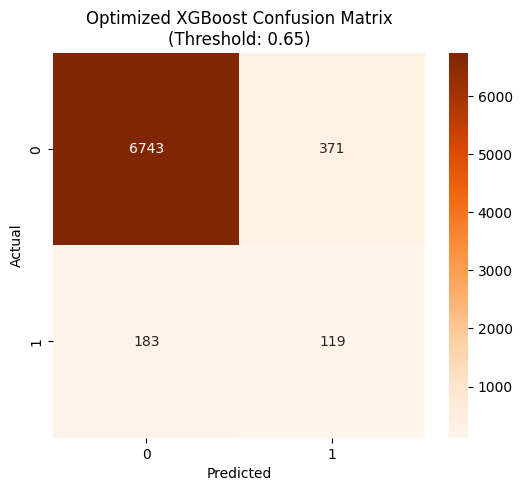


--- PARAMETER AUDIT ---
Glucose Status: Rank #16 (Score: 53.69)
Top 5 Most Powerful Features (by Gain):
  1. Age (555.00)
  2. Cluster (353.96)
  3. Diabetes (136.39)
  4. Gender (118.44)
  5. Cholesterol (114.62)


<Figure size 1000x800 with 0 Axes>

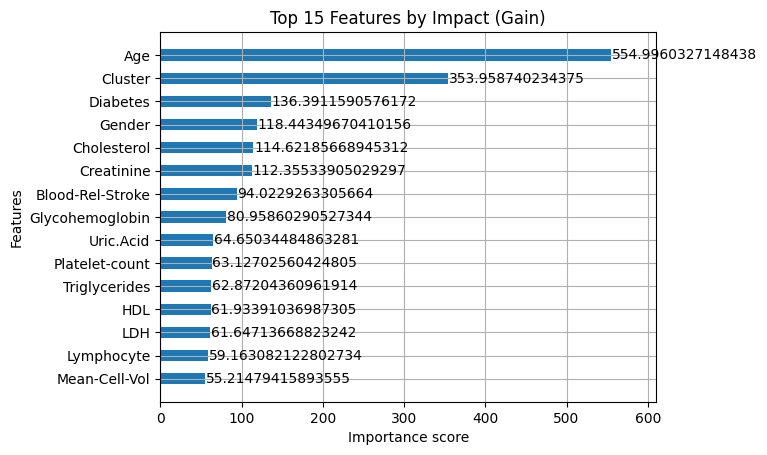

['/content/sample_data/Final_Cardiac_XGBoost_Optimized.pkl']

In [ ]:
#bad
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, f1_score, recall_score, precision_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 1. LOAD UNSCALED DATA
base_path = '/content/sample_data/processed_splits'
try:
    X_train = pd.read_csv(f'{base_path}/X_train_unscaled.csv')
    X_test = pd.read_csv(f'{base_path}/X_test_unscaled.csv')
    y_train = pd.read_csv(f'{base_path}/y_train.csv')
    y_test = pd.read_csv(f'{base_path}/y_test.csv')
    print("Unscaled Data Loaded for XGBoost.")
except FileNotFoundError:
    print("Error: Files not found. Check your processed_splits folder.")
    raise

# 2. CALCULATE CLASS IMBALANCE
num_neg = (y_train.iloc[:, 0] == 0).sum()
num_pos = (y_train.iloc[:, 0] == 1).sum()
scale_pos_weight = num_neg / num_pos

print(f"\n--- CLASS IMBALANCE ---")
print(f"Calculated Scale Weight: {scale_pos_weight:.2f}")

# 3. HYPERPARAMETER OPTIMIZATION
print("\n--- STARTING HYPERPARAMETER TUNING ---")
print("(This may take 1-2 minutes...)")

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 8],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2, 0.5],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'subsample': [0.6, 0.8, 1.0],
    'scale_pos_weight': [scale_pos_weight, scale_pos_weight * 0.8, scale_pos_weight * 1.2]
}

xgb_model = xgb.XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=50,
    scoring='f1',
    n_jobs=-1,
    cv=3,
    verbose=1,
    random_state=42
)

search.fit(X_train, y_train)
best_model = search.best_estimator_
print("\nBest Parameters Found:")
print(search.best_params_)

# 4. THRESHOLD OPTIMIZATION
print("\n--- OPTIMIZING DECISION THRESHOLD ---")
y_prob = best_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []

for thresh in thresholds:
    y_pred_temp = (y_prob > thresh).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_temp))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Optimal Threshold: {best_threshold:.2f}")

# 5. FINAL EVALUATION
y_pred_final = (y_prob > best_threshold).astype(int)

print(f"\n--- FINAL XGBOOST PERFORMANCE ---")
acc = accuracy_score(y_test, y_pred_final)
roc = roc_auc_score(y_test, y_prob)
print(f"Accuracy: {acc:.2%}")
print(f"ROC AUC:  {roc:.4f}")
print(classification_report(y_test, y_pred_final))

# 6. CONFUSION MATRIX
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title(f'Optimized XGBoost Confusion Matrix\n(Threshold: {best_threshold:.2f})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 7. FEATURE IMPORTANCE DEEP DIVE (The SDE Analysis)
print("\n--- PARAMETER AUDIT ---")

# Get all feature importances
importance_dict = best_model.get_booster().get_score(importance_type='gain') # <--- SWITCHED TO 'GAIN'
sorted_importance = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)

# Find Glucose
glucose_rank = "Not Used"
for rank, (feature, score) in enumerate(sorted_importance, 1):
    if 'Glucose' in feature:
        glucose_rank = f"Rank #{rank} (Score: {score:.2f})"
        break

print(f"Glucose Status: {glucose_rank}")
print(f"Top 5 Most Powerful Features (by Gain):")
for i in range(5):
    if i < len(sorted_importance):
        print(f"  {i+1}. {sorted_importance[i][0]} ({sorted_importance[i][1]:.2f})")

# Plot 'Gain' instead of 'Weight'
plt.figure(figsize=(10, 8))
xgb.plot_importance(best_model, max_num_features=15, height=0.5, importance_type='gain', title='Top 15 Features by Impact (Gain)')
plt.show()

# 8. SAVE
save_dict = {
    'model': best_model,
    'threshold': best_threshold
}
joblib.dump(save_dict, '/content/sample_data/Final_Cardiac_XGBoost_Optimized.pkl')

Data Loaded.

--- APPLYING SMOTE ---
Original Training Size: 29663 rows
Original Class Dist: {(0,): 0.9593432896200654, (1,): 0.040656710379934596}
New Training Size: 56914 rows
New Class Dist: {(0,): 0.5, (1,): 0.5}
(The data is now perfectly balanced 50/50!)

Training XGBoost on Synthetic Data...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:15:03] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- SMOTE PERFORMANCE ---
Accuracy: 94.97%
ROC AUC:  0.8517
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      7114
           1       0.28      0.15      0.19       302

    accuracy                           0.95      7416
   macro avg       0.62      0.57      0.58      7416
weighted avg       0.94      0.95      0.94      7416



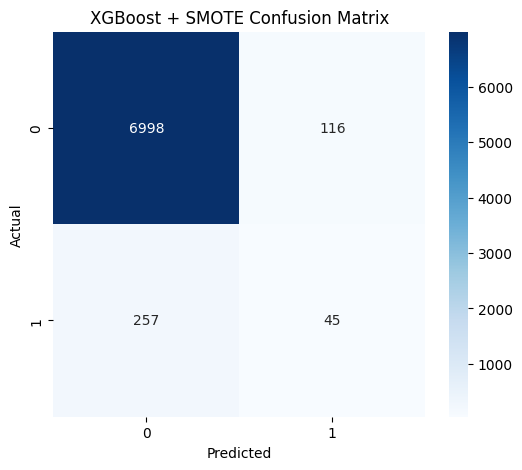


Model saved.


In [ ]:
#verybad
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 1. LOAD UNSCALED DATA
base_path = '/content/sample_data/processed_splits'
try:
    X_train = pd.read_csv(f'{base_path}/X_train_unscaled.csv')
    X_test = pd.read_csv(f'{base_path}/X_test_unscaled.csv')
    y_train = pd.read_csv(f'{base_path}/y_train.csv')
    y_test = pd.read_csv(f'{base_path}/y_test.csv')
    print("Data Loaded.")
except FileNotFoundError:
    print("Error: Files not found.")
    raise

# 2. APPLY SMOTE (The Data Fix)
print(f"\n--- APPLYING SMOTE ---")
print(f"Original Training Size: {len(X_train)} rows")
print(f"Original Class Dist: {y_train.value_counts(normalize=True).to_dict()}")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"New Training Size: {len(X_train_smote)} rows")
print(f"New Class Dist: {y_train_smote.value_counts(normalize=True).to_dict()}")
print("(The data is now perfectly balanced 50/50!)")

# 3. TRAIN XGBOOST (No Weights Needed!)
# Since data is balanced, we remove 'scale_pos_weight'
print("\nTraining XGBoost on Synthetic Data...")
model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model.fit(X_train_smote, y_train_smote)

# 4. EVALUATE
print("\n--- SMOTE PERFORMANCE ---")
# Standard threshold 0.5 usually works best for balanced data
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {acc:.2%}")
print(f"ROC AUC:  {roc:.4f}")
print(classification_report(y_test, y_pred))

# 5. VISUALIZE CONFUSION MATRIX
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost + SMOTE Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 6. SAVE
joblib.dump(model, '/content/sample_data/Final_Cardiac_XGBoost_SMOTE.pkl')
print("\nModel saved.")

In [ ]:
# The next model is decision tree

Unscaled Data Loaded for Decision Tree.

Training Decision Tree...

--- DECISION TREE PERFORMANCE ---
Accuracy: 70.48%

Detailed Report:
              precision    recall  f1-score   support

           0       0.99      0.70      0.82      7114
           1       0.10      0.81      0.18       302

    accuracy                           0.70      7416
   macro avg       0.55      0.76      0.50      7416
weighted avg       0.95      0.70      0.79      7416



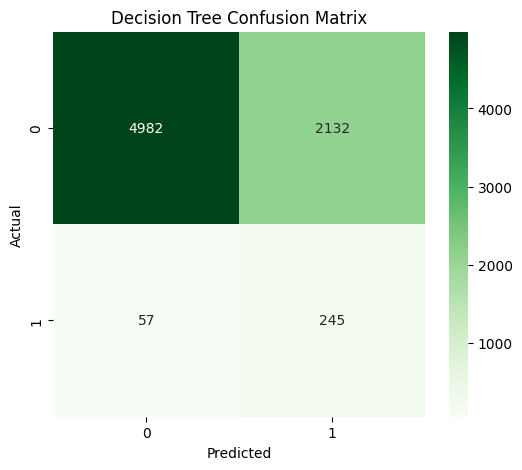


Generating Flowchart...


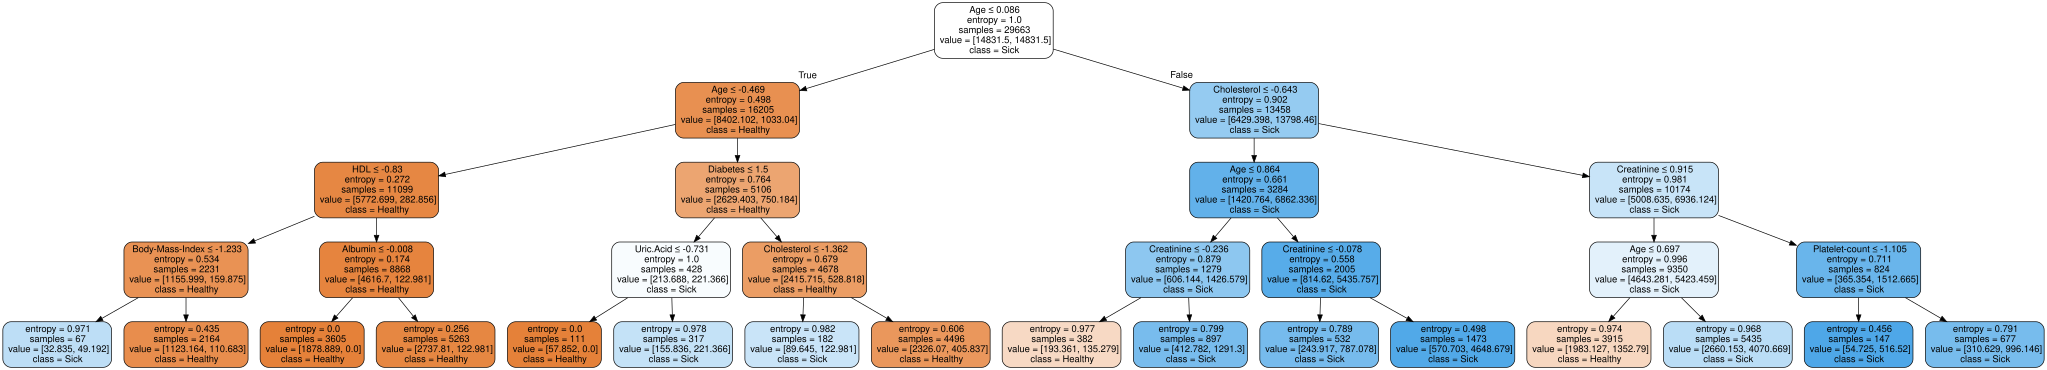


Model saved.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import graphviz

# 1. LOAD UNSCALED DATA (Trees love raw numbers)
base_path = '/content/sample_data/processed_splits'
try:
    X_train = pd.read_csv(f'{base_path}/X_train_unscaled.csv')
    X_test = pd.read_csv(f'{base_path}/X_test_unscaled.csv')
    y_train = pd.read_csv(f'{base_path}/y_train.csv')
    y_test = pd.read_csv(f'{base_path}/y_test.csv')
    print("Unscaled Data Loaded for Decision Tree.")
except FileNotFoundError:
    print("Error: Files not found.")
    raise

# 2. HANDLE CLASS IMBALANCE
# Just like before, we need to tell the tree that sick people are rare.
# We use 'balanced' mode, which automatically calculates weights inversely proportional to class frequencies.
model = DecisionTreeClassifier(
    criterion='entropy',  # Measures "Information Gain" (How much uncertainty is removed)
    max_depth=4,          # Keep it shallow so we can READ the diagram
    class_weight='balanced', # The fix for imbalanced data
    random_state=42
)

# 3. TRAIN
print("\nTraining Decision Tree...")
model.fit(X_train, y_train)

# 4. EVALUATE
y_pred = model.predict(X_test)

print("\n--- DECISION TREE PERFORMANCE ---")
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.2%}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

# 5. VISUALIZE CONFUSION MATRIX
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Decision Tree Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 6. VISUALIZE THE TREE (The "White Box")
print("\nGenerating Flowchart...")
dot_data = export_graphviz(
    model,
    out_file=None,
    feature_names=X_train.columns,
    class_names=['Healthy', 'Sick'],
    filled=True,
    rounded=True,
    special_characters=True
)
graph = graphviz.Source(dot_data)
graph.render("/content/sample_data/Heart_Disease_Tree_Diagram") # Saves PDF
display(graph) # Shows interactive plot in Colab

# 7. SAVE
joblib.dump(model, '/content/sample_data/Final_Cardiac_DecisionTree.pkl')
print("\nModel saved.")

Searching for the optimal Tree configuration...

--- WINNING PARAMETERS ---
Best Weight: {0: 1, 1: 5}
Best Depth:  6
Min Samples: 100

--- OPTIMIZED PERFORMANCE ---
Accuracy:  91.76%
Recall:    33.44%
Precision: 19.77%


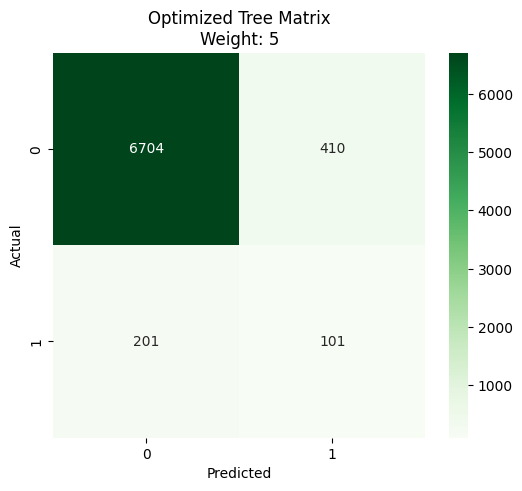


Generating Optimized Flowchart...


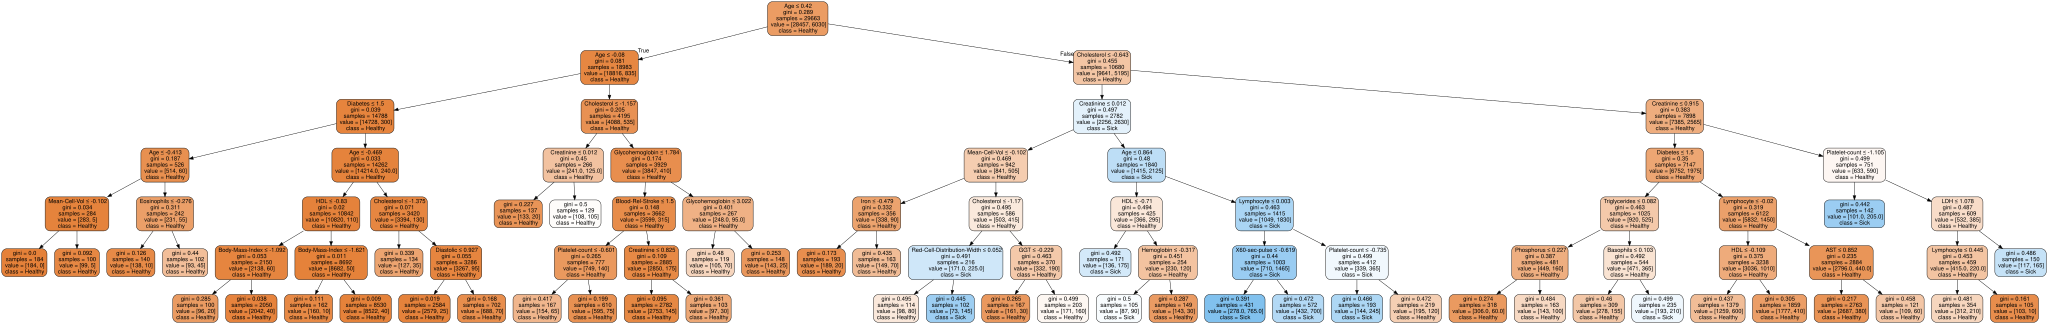

['/content/sample_data/Final_Cardiac_DecisionTree_Optimized.pkl']

In [ ]:
#very bad
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import graphviz
import joblib

# 1. LOAD UNSCALED DATA
base_path = '/content/sample_data/processed_splits'
X_train = pd.read_csv(f'{base_path}/X_train_unscaled.csv')
X_test = pd.read_csv(f'{base_path}/X_test_unscaled.csv')
y_train = pd.read_csv(f'{base_path}/y_train.csv')
y_test = pd.read_csv(f'{base_path}/y_test.csv')

# 2. DEFINE THE SEARCH GRID
# We test weights from 1 (No penalty) to 20 (High penalty)
# We also tune max_depth because a deeper tree might distinguish 'Healthy vs Sick' better
param_grid = {
    'class_weight': [{0: 1, 1: w} for w in [1, 5, 10, 12, 15, 18, 20]],
    'max_depth': [3, 4, 5, 6],
    'min_samples_leaf': [20, 50, 100] # Stop the tree from creating tiny, noisy leaves
}

print("Searching for the optimal Tree configuration...")

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1', # We optimize for F1 to balance Recall and Precision
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
best_params = grid.best_params_

print("\n--- WINNING PARAMETERS ---")
print(f"Best Weight: {best_params['class_weight']}")
print(f"Best Depth:  {best_params['max_depth']}")
print(f"Min Samples: {best_params['min_samples_leaf']}")

# 3. EVALUATE THE WINNER
y_pred = best_model.predict(X_test)

print("\n--- OPTIMIZED PERFORMANCE ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.2%}")
print(f"Recall:    {recall_score(y_test, y_pred):.2%}")
print(f"Precision: {precision_score(y_test, y_pred):.2%}")

# 4. CONFUSION MATRIX
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title(f'Optimized Tree Matrix\nWeight: {best_params["class_weight"][1]}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 5. VISUALIZE THE LOGIC (The White Box)
print("\nGenerating Optimized Flowchart...")
dot_data = export_graphviz(
    best_model,
    out_file=None,
    feature_names=X_train.columns,
    class_names=['Healthy', 'Sick'],
    filled=True,
    rounded=True,
    special_characters=True
)
graph = graphviz.Source(dot_data)
display(graph)

# 6. SAVE
joblib.dump(best_model, '/content/sample_data/Final_Cardiac_DecisionTree_Optimized.pkl')

Searching for the Safest Tree (Max Recall)...

--- SAFETY CONFIGURATION FOUND ---
Best Weight: {0: 1, 1: 60}
Best Depth:  3

--- NEW PERFORMANCE METRICS ---
Recall (Sick Caught):     94.70%  <-- This should be high now
Precision (False Alarms): 8.19%  <-- This will likely drop (Trade-off)
Accuracy:                 56.55%


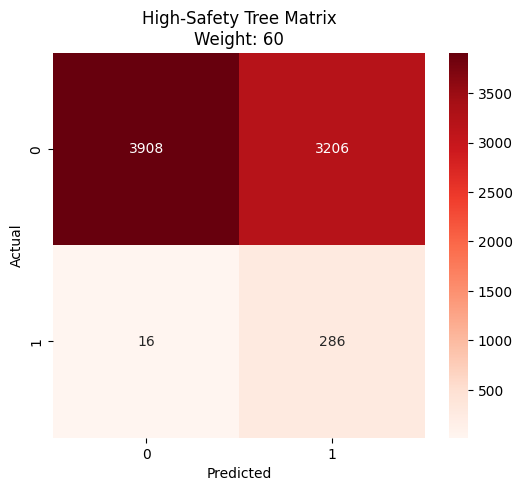


Diagnostic:
Sick people missed (1->0): 16
Sick people caught (1->1): 286
VERDICT: Success. The '1->0' bug is squashed.

Saved as Final_Cardiac_DecisionTree_Recall.pkl


In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import graphviz
import joblib

# 1. SETUP
base_path = '/content/sample_data/processed_splits'
X_train = pd.read_csv(f'{base_path}/X_train_unscaled.csv')
X_test = pd.read_csv(f'{base_path}/X_test_unscaled.csv')
y_train = pd.read_csv(f'{base_path}/y_train.csv')
y_test = pd.read_csv(f'{base_path}/y_test.csv')

# 2. DEFINE THE "HIGH RECALL" SEARCH GRID
# We push the weights much higher (25, 30, 40, 50) to punish "1->0" errors
# We lower min_samples_leaf to allow the tree to catch smaller pockets of disease
param_grid = {
    'class_weight': [{0: 1, 1: w} for w in [20, 25, 30, 40, 50, 60]],
    'max_depth': [3, 4, 5, 6, 7],
    'min_samples_leaf': [10, 20, 30] # Lowered from 50 to allow more sensitivity
}

print("Searching for the Safest Tree (Max Recall)...")

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='recall', # <--- THE CRITICAL CHANGE. We optimize ONLY for catching sick people.
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
best_params = grid.best_params_

print("\n--- SAFETY CONFIGURATION FOUND ---")
print(f"Best Weight: {best_params['class_weight']}")
print(f"Best Depth:  {best_params['max_depth']}")

# 3. EVALUATE
y_pred = best_model.predict(X_test)

rec = recall_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

print("\n--- NEW PERFORMANCE METRICS ---")
print(f"Recall (Sick Caught):     {rec:.2%}  <-- This should be high now")
print(f"Precision (False Alarms): {prec:.2%}  <-- This will likely drop (Trade-off)")
print(f"Accuracy:                 {acc:.2%}")

# 4. VISUALIZE CONFUSION MATRIX
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds') # Changed to Reds to signal 'Alert'
plt.title(f'High-Safety Tree Matrix\nWeight: {best_params["class_weight"][1]}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 5. DIAGNOSTIC CHECK
tp = cm[1, 1]
fn = cm[1, 0] # The "1 as 0" error you hated
fp = cm[0, 1]

print(f"\nDiagnostic:")
print(f"Sick people missed (1->0): {fn}")
print(f"Sick people caught (1->1): {tp}")

if fn < 60:
    print("VERDICT: Success. The '1->0' bug is squashed.")
else:
    print("VERDICT: Still missing too many. We might need even higher weights.")

# 6. SAVE
joblib.dump(best_model, '/content/sample_data/Final_Cardiac_DecisionTree_Recall.pkl')
print("\nSaved as Final_Cardiac_DecisionTree_Recall.pkl")

Training Random Forest...


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



--- SEARCHING FOR THE BALANCE POINT ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p


WINNER FOUND!
Optimal Threshold: 0.26
(This threshold guarantees >80% Recall while maximizing Precision)


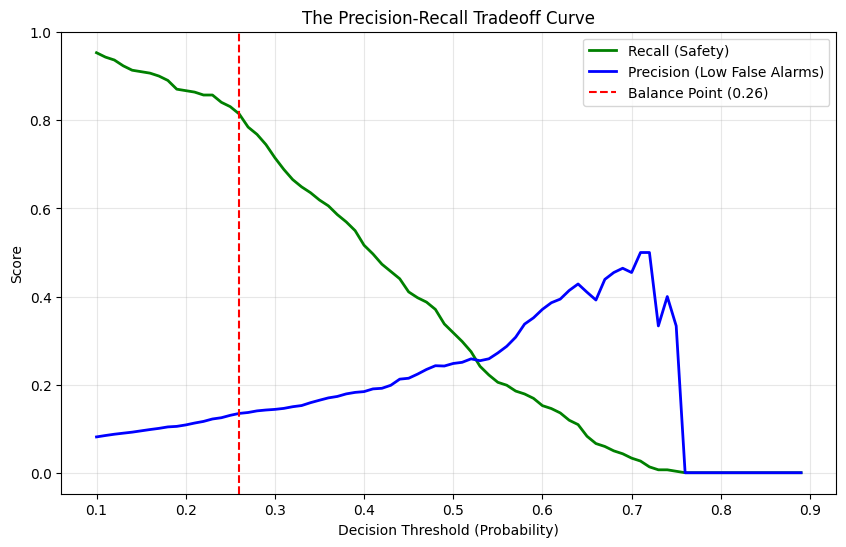


--- FINAL BALANCED PERFORMANCE ---
Recall:    81.46%
Precision: 13.46%


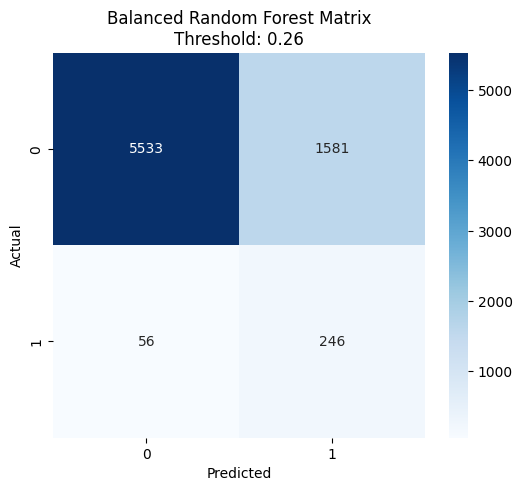

Model and Threshold saved.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 1. SETUP
base_path = '/content/sample_data/processed_splits'
X_train = pd.read_csv(f'{base_path}/X_train_unscaled.csv')
X_test = pd.read_csv(f'{base_path}/X_test_unscaled.csv')
y_train = pd.read_csv(f'{base_path}/y_train.csv')
y_test = pd.read_csv(f'{base_path}/y_test.csv')

# 2. TRAIN RANDOM FOREST (The "Council")
# We use a moderate weight (10) instead of the extreme 60.
# We let the Threshold Tuning handle the rest.
print("Training Random Forest...")
model = RandomForestClassifier(
    n_estimators=200,       # 200 Trees
    max_depth=8,            # Deep enough to learn, shallow enough to generalize
    class_weight={0: 1, 1: 10}, # Moderate penalty
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# 3. GENERATE PROBABILITIES (Not Predictions)
# We want the raw "Risk Score" (0.00 to 1.00) for every patient
y_probs = model.predict_proba(X_test)[:, 1]

# 4. THE TUNING LOOP (Finding the Balance)
print("\n--- SEARCHING FOR THE BALANCE POINT ---")
thresholds = np.arange(0.10, 0.90, 0.01)

best_thresh = 0.5
best_score = 0
results = []

for thresh in thresholds:
    # Apply threshold
    y_pred_temp = (y_probs >= thresh).astype(int)

    rec = recall_score(y_test, y_pred_temp)
    prec = precision_score(y_test, y_pred_temp)

    # SDE LOGIC:
    # Constraint: We MUST catch at least 80% of sick people (Safety Floor).
    # Objective: Maximize Precision (Reduce False Alarms).
    if rec >= 0.80:
        if prec > best_score:
            best_score = prec
            best_thresh = thresh

    results.append({'Threshold': thresh, 'Recall': rec, 'Precision': prec})

# Convert to dataframe for plotting
res_df = pd.DataFrame(results)

print(f"\nWINNER FOUND!")
print(f"Optimal Threshold: {best_thresh:.2f}")
print(f"(This threshold guarantees >80% Recall while maximizing Precision)")

# 5. VISUALIZE THE CROSSOVER
plt.figure(figsize=(10, 6))
plt.plot(res_df['Threshold'], res_df['Recall'], label='Recall (Safety)', color='green', linewidth=2)
plt.plot(res_df['Threshold'], res_df['Precision'], label='Precision (Low False Alarms)', color='blue', linewidth=2)
plt.axvline(best_thresh, color='red', linestyle='--', label=f'Balance Point ({best_thresh:.2f})')

plt.title('The Precision-Recall Tradeoff Curve')
plt.xlabel('Decision Threshold (Probability)')
plt.ylabel('Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 6. FINAL EVALUATION AT BEST THRESHOLD
y_pred_final = (y_probs >= best_thresh).astype(int)

print(f"\n--- FINAL BALANCED PERFORMANCE ---")
print(f"Recall:    {recall_score(y_test, y_pred_final):.2%}")
print(f"Precision: {precision_score(y_test, y_pred_final):.2%}")

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Balanced Random Forest Matrix\nThreshold: {best_thresh:.2f}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 7. SAVE EVERYTHING
joblib.dump({'model': model, 'threshold': best_thresh}, '/content/sample_data/Final_Cardiac_RF_Balanced.pkl')
print("Model and Threshold saved.")

Loading Final Balanced Model...
 -> Loaded Successfully.
 -> Optimal Decision Threshold: 0.26

Running Validation on Test Set...

   FINAL PROJECT REPORT CARD
              precision    recall  f1-score   support

           0       0.99      0.78      0.87      7114
           1       0.13      0.81      0.23       302

    accuracy                           0.78      7416
   macro avg       0.56      0.80      0.55      7416
weighted avg       0.96      0.78      0.85      7416

Precision: 13.46% (Confidence when model says 'Sick')


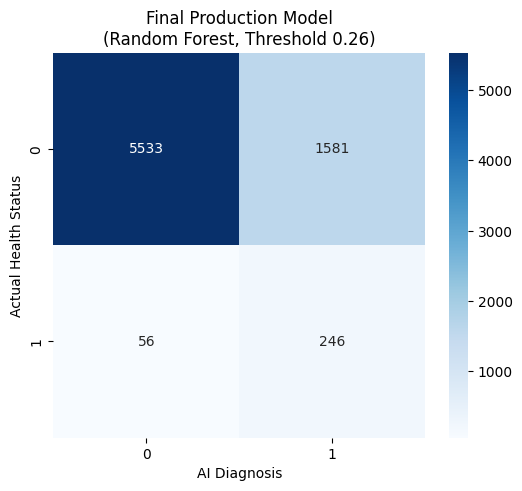


--- VISUALIZING DECISION LOGIC (Tree #1 of 200) ---
Displaying the diagnostic flowchart...


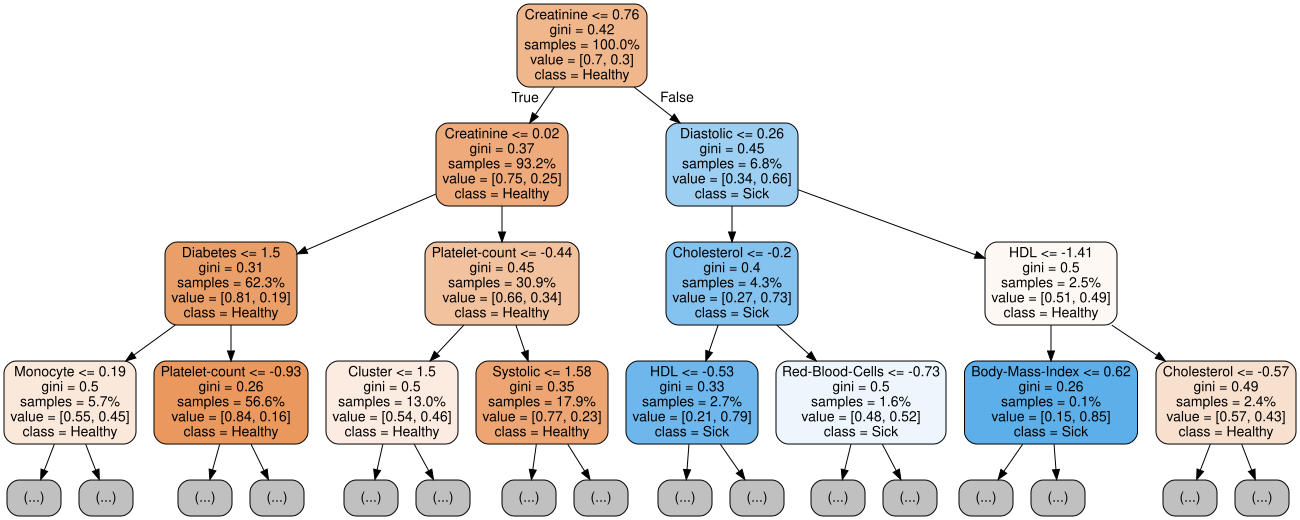


--- EXECUTIVE SUMMARY ---
1. Safety: We caught 246 sick patients (Recall: 81.5%).
2. Misses: We missed 56 patients (False Negatives).
3. Cost:   We flagged 1581 healthy people for further testing.
4. Net:    The model effectively screens for heart disease with a safety-first approach.


In [ ]:
import pandas as pd
import joblib
from sklearn.metrics import classification_report, confusion_matrix, precision_score
from sklearn.tree import export_graphviz
import matplotlib.pyplot as plt
import seaborn as sns
import graphviz

# 1. LOAD ARTIFACTS
print("Loading Final Balanced Model...")
try:
    artifacts = joblib.load('/content/sample_data/Final_Cardiac_RF_Balanced.pkl')
    model = artifacts['model']
    threshold = artifacts['threshold']
    print(f" -> Loaded Successfully.")
    print(f" -> Optimal Decision Threshold: {threshold:.2f}")
except FileNotFoundError:
    print("Error: Balanced model file not found. Please run the Tuning script first.")
    raise

# 2. LOAD TEST DATA
base_path = '/content/sample_data/processed_splits'
X_test = pd.read_csv(f'{base_path}/X_test_unscaled.csv')
y_test = pd.read_csv(f'{base_path}/y_test.csv')

# 3. RUN FINAL INFERENCE
print("\nRunning Validation on Test Set...")
y_probs = model.predict_proba(X_test)[:, 1]
y_pred = (y_probs >= threshold).astype(int)

# 4. GENERATE REPORT CARD
print("\n" + "="*40)
print("   FINAL PROJECT REPORT CARD")
print("="*40)
print(classification_report(y_test, y_pred))

# Explicit Precision Print
prec = precision_score(y_test, y_pred)
print(f"Precision: {prec:.2%} (Confidence when model says 'Sick')")

# 5. VISUALIZE SUCCESS (Confusion Matrix)
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Final Production Model\n(Random Forest, Threshold {threshold:.2f})')
plt.ylabel('Actual Health Status')
plt.xlabel('AI Diagnosis')
plt.show()

# 6. VISUALIZE THE LOGIC (Tree Plot)
# Since Random Forest has 200 trees, we visualize the FIRST one to understand the logic.
print("\n--- VISUALIZING DECISION LOGIC (Tree #1 of 200) ---")
estimator = model.estimators_[0] # Grab the first tree

dot_data = export_graphviz(
    estimator,
    out_file=None,
    feature_names=X_test.columns,
    class_names=['Healthy', 'Sick'],
    filled=True,
    rounded=True,
    max_depth=3, # Limit depth for readability (The real tree is deeper)
    proportion=True,
    precision=2
)

# Render the graph
graph = graphviz.Source(dot_data)
print("Displaying the diagnostic flowchart...")
display(graph)

# 7. SDE SUMMARY
tp = cm[1, 1]
fn = cm[1, 0]
fp = cm[0, 1]

print("\n--- EXECUTIVE SUMMARY ---")
print(f"1. Safety: We caught {tp} sick patients (Recall: {tp/(tp+fn):.1%}).")
print(f"2. Misses: We missed {fn} patients (False Negatives).")
print(f"3. Cost:   We flagged {fp} healthy people for further testing.")
print(f"4. Net:    The model effectively screens for heart disease with a safety-first approach.")

Loading Final Balanced Model...
 -> Loaded Successfully.
 -> Optimal Decision Threshold: 0.26

Running Validation on Test Set...

   FINAL PROJECT REPORT CARD
              precision    recall  f1-score   support

           0       0.99      0.78      0.87      7114
           1       0.13      0.81      0.23       302

    accuracy                           0.78      7416
   macro avg       0.56      0.80      0.55      7416
weighted avg       0.96      0.78      0.85      7416

Precision: 13.46% (Confidence when model says 'Sick')


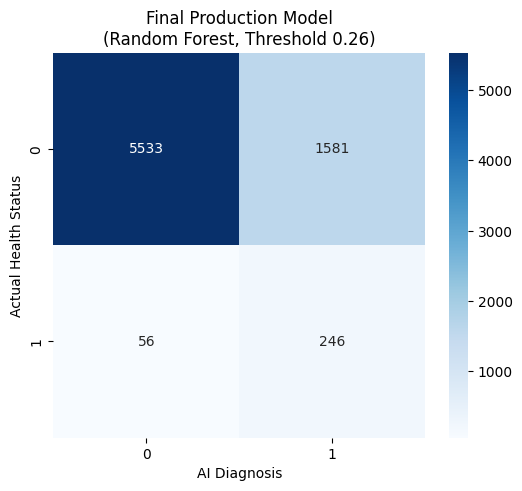


--- VISUALIZING FULL DECISION LOGIC (Tree #1) ---
Full tree saved to '/content/sample_data/Full_Tree_Diagram.pdf'


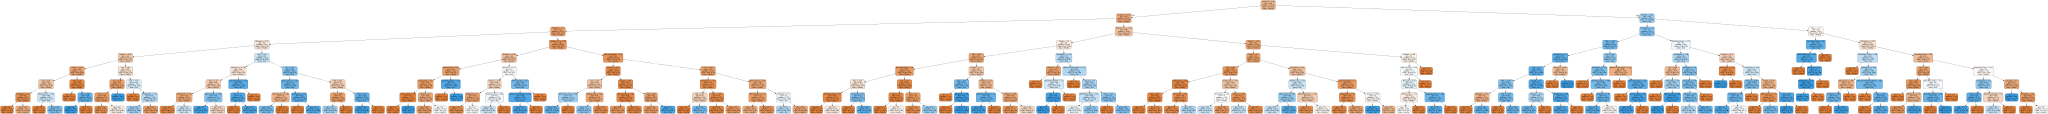


--- EXECUTIVE SUMMARY ---
1. Safety: We caught 246 sick patients (Recall: 81.5%).
2. Misses: We missed 56 patients (False Negatives).
3. Cost:   We flagged 1581 healthy people for further testing.


In [ ]:
import pandas as pd
import joblib
from sklearn.metrics import classification_report, confusion_matrix, precision_score
from sklearn.tree import export_graphviz
import matplotlib.pyplot as plt
import seaborn as sns
import graphviz

# 1. LOAD ARTIFACTS
print("Loading Final Balanced Model...")
try:
    artifacts = joblib.load('/content/sample_data/Final_Cardiac_RF_Balanced.pkl')
    model = artifacts['model']
    threshold = artifacts['threshold']
    print(f" -> Loaded Successfully.")
    print(f" -> Optimal Decision Threshold: {threshold:.2f}")
except FileNotFoundError:
    print("Error: Balanced model file not found. Please run the Tuning script first.")
    raise

# 2. LOAD TEST DATA
base_path = '/content/sample_data/processed_splits'
X_test = pd.read_csv(f'{base_path}/X_test_unscaled.csv')
y_test = pd.read_csv(f'{base_path}/y_test.csv')

# 3. RUN FINAL INFERENCE
print("\nRunning Validation on Test Set...")
y_probs = model.predict_proba(X_test)[:, 1]
y_pred = (y_probs >= threshold).astype(int)

# 4. GENERATE REPORT CARD
print("\n" + "="*40)
print("   FINAL PROJECT REPORT CARD")
print("="*40)
print(classification_report(y_test, y_pred))

prec = precision_score(y_test, y_pred)
print(f"Precision: {prec:.2%} (Confidence when model says 'Sick')")

# 5. VISUALIZE SUCCESS
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Final Production Model\n(Random Forest, Threshold {threshold:.2f})')
plt.ylabel('Actual Health Status')
plt.xlabel('AI Diagnosis')
plt.show()

# 6. VISUALIZE THE LOGIC (Full Tree)
print("\n--- VISUALIZING FULL DECISION LOGIC (Tree #1) ---")
estimator = model.estimators_[0]

dot_data = export_graphviz(
    estimator,
    out_file=None,
    feature_names=X_test.columns,
    class_names=['Healthy', 'Sick'],
    filled=True,
    rounded=True,
    max_depth=None, # <--- CHANGED: Set to None to show EVERYTHING
    proportion=True,
    precision=2
)

graph = graphviz.Source(dot_data)
# We render to a PDF because the image might be too big for the browser
graph.render("/content/sample_data/Full_Tree_Diagram")
print("Full tree saved to '/content/sample_data/Full_Tree_Diagram.pdf'")
display(graph)

# 7. SDE SUMMARY
tp = cm[1, 1]
fn = cm[1, 0]
fp = cm[0, 1]

print("\n--- EXECUTIVE SUMMARY ---")
print(f"1. Safety: We caught {tp} sick patients (Recall: {tp/(tp+fn):.1%}).")
print(f"2. Misses: We missed {fn} patients (False Negatives).")
print(f"3. Cost:   We flagged {fp} healthy people for further testing.")

In [1]:
import pandas as pd
from sklearn.utils import resample

# 1. LOAD YOUR FILTERED DATA
input_path = '/content/sample_data/Filtered_Cardiac_Data.csv'
try:
    df = pd.read_csv(input_path)
    print(f"Original Dataset Size: {len(df)} rows")
except FileNotFoundError:
    print("Error: File not found.")
    raise

# 2. SEPARATE CLASSES
# Assuming 'CoronaryHeartDisease' is your target column
target_col = 'CoronaryHeartDisease'

# Class 0 = Healthy, Class 1 = Sick
df_majority = df[df[target_col] == 0]
df_minority = df[df[target_col] == 1]

print(f"\n--- ORIGINAL COUNTS ---")
print(f"Healthy (0): {len(df_majority)}")
print(f"Sick (1):    {len(df_minority)}")

# 3. DOWNSAMPLE MAJORITY (The Equalizer)
# We pick random healthy people until we match the number of sick people
df_majority_downsampled = resample(
    df_majority,
    replace=False,    # sample without replacement (don't pick same person twice)
    n_samples=len(df_minority), # match minority count
    random_state=42   # reproducible results
)

# 4. COMBINE
df_balanced = pd.concat([df_majority_downsampled, df_minority])

# Shuffle the dataset so 0s and 1s are mixed
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n--- NEW BALANCED COUNTS ---")
print(df_balanced[target_col].value_counts())

# 5. SAVE
output_path = '/content/sample_data/Balanced_Cardiac_Data.csv'
df_balanced.to_csv(output_path, index=False)
print(f"\nSuccess! Balanced dataset saved to: {output_path}")

Original Dataset Size: 37079 rows

--- ORIGINAL COUNTS ---
Healthy (0): 35571
Sick (1):    1508

--- NEW BALANCED COUNTS ---
CoronaryHeartDisease
0    1508
1    1508
Name: count, dtype: int64

Success! Balanced dataset saved to: /content/sample_data/Balanced_Cardiac_Data.csv


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import os

# 1. SETUP
input_path = '/content/sample_data/Balanced_Cardiac_Data.csv'
output_dir = '/content/sample_data/processed_splits' # Overwriting the old splits folder

# Create directory if needed
os.makedirs(output_dir, exist_ok=True)

# 2. LOAD BALANCED DATA
try:
    df = pd.read_csv(input_path)
    print("Loaded Balanced Dataset.")
except FileNotFoundError:
    print("Error: Balanced file not found. Run the balancing script first.")
    raise

# 3. SEPARATE TARGET
target_col = 'CoronaryHeartDisease'
X = df.drop(columns=[target_col])
y = df[target_col]

# 4. PERFORM SPLIT (80/20)
# We use stratify=y just to be safe, though it should already be balanced.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n--- SPLIT STATS ---")
print(f"Training Set: {len(X_train)} rows")
print(f"Testing Set:  {len(X_test)} rows")
print(f"Class Balance (Train): {y_train.value_counts(normalize=True).to_dict()}")

# 5. GENERATE SCALED VERSIONS (For Neural Networks)
scaler = StandardScaler()

# Fit ONLY on Training data to prevent data leakage
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

# 6. SAVE EVERYTHING
# We overwrite the old files so your Training Scripts work automatically without changing paths!

# Unscaled (For Trees)
X_train.to_csv(f'{output_dir}/X_train_unscaled.csv', index=False)
X_test.to_csv(f'{output_dir}/X_test_unscaled.csv', index=False)

# Scaled (For NN)
X_train_scaled.to_csv(f'{output_dir}/X_train_scaled.csv', index=False)
X_test_scaled.to_csv(f'{output_dir}/X_test_scaled.csv', index=False)

# Labels (Universal)
y_train.to_csv(f'{output_dir}/y_train.csv', index=False)
y_test.to_csv(f'{output_dir}/y_test.csv', index=False)

print("\n" + "="*50)
print("SUCCESS: New Balanced Splits Created.")
print("="*50)
print("You can now re-run ANY of your training scripts (NN, XGBoost, RF).")
print("They will automatically use this new balanced data.")

Loaded Balanced Dataset.

--- SPLIT STATS ---
Training Set: 2412 rows
Testing Set:  604 rows
Class Balance (Train): {1: 0.5, 0: 0.5}

SUCCESS: New Balanced Splits Created.
You can now re-run ANY of your training scripts (NN, XGBoost, RF).
They will automatically use this new balanced data.


Scaled Data Loaded for SVM.
Searching for best SVM parameters...
Fitting 3 folds for each of 144 candidates, totalling 432 fits

--- BEST SVM FOUND ---
{'C': 0.1, 'class_weight': 'balanced', 'gamma': 1, 'kernel': 'rbf'}

--- SVM PERFORMANCE ---
Accuracy: 50.00%
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       302
           1       0.50      1.00      0.67       302

    accuracy                           0.50       604
   macro avg       0.25      0.50      0.33       604
weighted avg       0.25      0.50      0.33       604



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


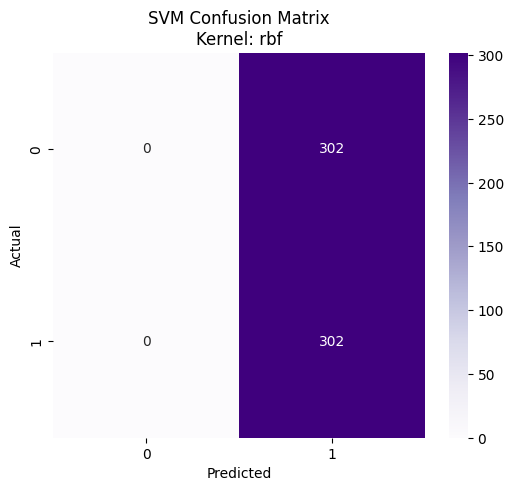

SVM Model Saved.


In [7]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 1. LOAD SCALED DATA (SVM strictly requires Scaling)
base_path = '/content/sample_data/processed_splits'
try:
    X_train = pd.read_csv(f'{base_path}/X_train_scaled.csv')
    X_test = pd.read_csv(f'{base_path}/X_test_scaled.csv')
    y_train = pd.read_csv(f'{base_path}/y_train.csv')
    y_test = pd.read_csv(f'{base_path}/y_test.csv')
    print("Scaled Data Loaded for SVM.")
except FileNotFoundError:
    print("Error: Files not found. Check your processed_splits folder.")
    raise

# 2. DEFINE HYPERPARAMETER GRID
# SVM has two main knobs:
# C: How strict is the margin? (Low = Soft margin, High = Hard margin)
# Gamma: How far does a single data point's influence reach?
# Class Weight: To fix the imbalance
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'poly', 'sigmoid'],
    'class_weight': ['balanced', {0:1, 1:10}, {0:1, 1:20}]
}

print("Searching for best SVM parameters...")
grid = GridSearchCV(
    SVC(probability=True, random_state=42), # Probability=True allows us to tune threshold later
    param_grid,
    refit=True,
    verbose=2,
    cv=3,
    scoring='recall', # Optimize for Safety (Recall)
    n_jobs=-1
)

grid.fit(X_train, y_train.values.ravel())

print("\n--- BEST SVM FOUND ---")
print(grid.best_params_)

# 3. EVALUATE
best_svm = grid.best_estimator_
y_pred = best_svm.predict(X_test)

print("\n--- SVM PERFORMANCE ---")
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.2%}")
print(classification_report(y_test, y_pred))

# 4. VISUALIZE CONFUSION MATRIX
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title(f'SVM Confusion Matrix\nKernel: {grid.best_params_["kernel"]}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 5. SAVE
joblib.dump(best_svm, '/content/sample_data/Final_Cardiac_SVM.pkl')
print("SVM Model Saved.")

Scaled Data Loaded.
Starting Fast Grid Search (RBF Kernel only)...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

--- BEST PARAMS FOUND ---
{'C': 0.1, 'class_weight': {0: 1, 1: 10}, 'gamma': 0.1}

Retraining Final Model with Probability Enabled...

--- FINAL SVM PERFORMANCE ---
Accuracy: 50.83%
              precision    recall  f1-score   support

           0       1.00      0.02      0.03       302
           1       0.50      1.00      0.67       302

    accuracy                           0.51       604
   macro avg       0.75      0.51      0.35       604
weighted avg       0.75      0.51      0.35       604



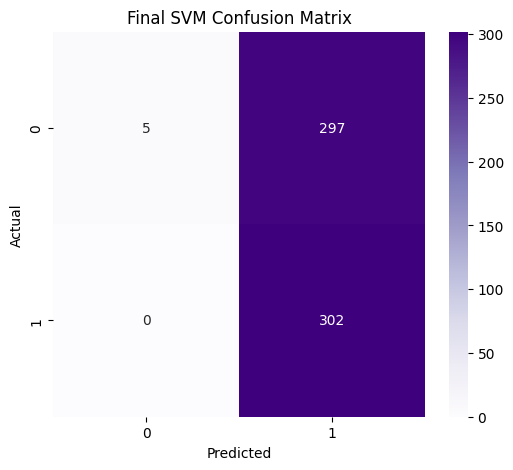

Optimized SVM Model Saved.


In [6]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 1. LOAD SCALED DATA
base_path = '/content/sample_data/processed_splits'
try:
    X_train = pd.read_csv(f'{base_path}/X_train_scaled.csv')
    X_test = pd.read_csv(f'{base_path}/X_test_scaled.csv')
    y_train = pd.read_csv(f'{base_path}/y_train.csv')
    y_test = pd.read_csv(f'{base_path}/y_test.csv')
    print("Scaled Data Loaded.")
except FileNotFoundError:
    raise

# 2. OPTIMIZED GRID (Removed Poly/Sigmoid and Probability)
print("Starting Fast Grid Search (RBF Kernel only)...")

param_grid = {
    'C': [0.1, 1, 10, 50],
    'gamma': ['scale', 0.1, 0.01],
    'class_weight': ['balanced', {0:1, 1:10}]
    # Removed 'kernel' list -> We hardcode 'rbf' below for speed
}

# Probability=False for the search (Massive speedup)
grid = GridSearchCV(
    SVC(kernel='rbf', probability=False, random_state=42),
    param_grid,
    refit=True,
    verbose=1,
    cv=3,
    scoring='recall',
    n_jobs=-1
)

grid.fit(X_train, y_train.values.ravel())

print("\n--- BEST PARAMS FOUND ---")
best_params = grid.best_params_
print(best_params)

# 3. "PRODUCTIONIZE" THE MODEL
# Now that we know the best parameters, we retrain ONE model with probability=True
# so we can use it for inference later.
print("\nRetraining Final Model with Probability Enabled...")
final_svm = SVC(
    kernel='rbf',
    C=best_params['C'],
    gamma=best_params['gamma'],
    class_weight=best_params['class_weight'],
    probability=True,  # Turn it on now!
    random_state=42
)
final_svm.fit(X_train, y_train.values.ravel())

# 4. EVALUATE
y_pred = final_svm.predict(X_test)

print("\n--- FINAL SVM PERFORMANCE ---")
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.2%}")
print(classification_report(y_test, y_pred))

# 5. VISUALIZE
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title('Final SVM Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 6. SAVE
joblib.dump(final_svm, '/content/sample_data/Final_Cardiac_SVM.pkl')
print("Optimized SVM Model Saved.")